In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib as mpl 
mpl.rcParams['figure.dpi'] = 400
import graphviz

# Exploração e limeza de dados

In [2]:
df = pd.read_excel('Data/default_of_credit_card_clients__courseware_version_1_21_19.xls')
df.shape

(30000, 25)

In [3]:
df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_1',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='object')

In [4]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,798fc410-45c1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,8a8c8f3b-8eb4,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,85698822-43f5,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,0737c11b-be42,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,3b7f77cc-dbc0,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [5]:
df['ID'].nunique()

29687

In [6]:
id_counts = df['ID'].value_counts()
id_counts.head()

ID
89f8f447-fca8    2
7c9b7473-cc2f    2
90330d02-82d9    2
75938fec-e5ec    2
2a793ecf-05c6    2
Name: count, dtype: int64

In [7]:
id_counts.value_counts()

count
1    29374
2      313
Name: count, dtype: int64

In [8]:
id_counts.index[0:5]

Index(['89f8f447-fca8', '7c9b7473-cc2f', '90330d02-82d9', '75938fec-e5ec',
       '2a793ecf-05c6'],
      dtype='object', name='ID')

In [9]:
#Mascaras booleanas
dupe_mask = id_counts == 2
dupe_mask[0:5]

ID
89f8f447-fca8    True
7c9b7473-cc2f    True
90330d02-82d9    True
75938fec-e5ec    True
2a793ecf-05c6    True
Name: count, dtype: bool

In [10]:
dupe_ids = list(id_counts.index[dupe_mask])
len(dupe_ids)

313

In [11]:
dupe_ids[0:5]

['89f8f447-fca8',
 '7c9b7473-cc2f',
 '90330d02-82d9',
 '75938fec-e5ec',
 '2a793ecf-05c6']

In [12]:
df.loc[df['ID'].isin(dupe_ids[0:3]), :].head(10)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
5033,89f8f447-fca8,320000,2,2,1,32,0,0,0,0,...,169371,172868,150827,8000,8000,5500,6100,6000,5000,0
5133,89f8f447-fca8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
15879,7c9b7473-cc2f,90000,2,1,1,29,0,0,0,0,...,27751,20292,14937,2967,2007,1429,1092,412,263,0
15979,7c9b7473-cc2f,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
29646,90330d02-82d9,70000,1,2,1,29,0,0,0,0,...,10694,27908,11192,2009,1404,3016,20001,2000,5002,0
29746,90330d02-82d9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [13]:
df_zero_mask = df == 0

In [14]:
feature_zero_mask = df_zero_mask.iloc[:, 1:].all(axis=1)
sum(feature_zero_mask)

315

In [15]:
df_clean_1 = df.loc[~feature_zero_mask, :].copy()
df_clean_1.shape

(29685, 25)

In [16]:
df_clean_1['ID'].nunique() 

29685

In [17]:
df_clean_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29685 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   ID                          29685 non-null  object
 1   LIMIT_BAL                   29685 non-null  int64 
 2   SEX                         29685 non-null  int64 
 3   EDUCATION                   29685 non-null  int64 
 4   MARRIAGE                    29685 non-null  int64 
 5   AGE                         29685 non-null  int64 
 6   PAY_1                       29685 non-null  object
 7   PAY_2                       29685 non-null  int64 
 8   PAY_3                       29685 non-null  int64 
 9   PAY_4                       29685 non-null  int64 
 10  PAY_5                       29685 non-null  int64 
 11  PAY_6                       29685 non-null  int64 
 12  BILL_AMT1                   29685 non-null  int64 
 13  BILL_AMT2                   29685 non-null  int64 


In [18]:
df_clean_1['PAY_1'].head(5)

0     2
1    -1
2     0
3     0
4    -1
Name: PAY_1, dtype: object

In [19]:
df_clean_1['PAY_1'].value_counts()

PAY_1
0                13087
-1                5047
1                 3261
Not available     3021
-2                2476
2                 2378
3                  292
4                   63
5                   23
8                   17
6                   11
7                    9
Name: count, dtype: int64

In [20]:
valid_pay_1_mask = df_clean_1['PAY_1'] != 'Not available'

In [21]:
valid_pay_1_mask[0:5]

0    True
1    True
2    True
3    True
4    True
Name: PAY_1, dtype: bool

In [22]:
sum(valid_pay_1_mask)

26664

In [23]:
df_clean_2 = df_clean_1.loc[valid_pay_1_mask, :].copy()
df_clean_2.shape

(26664, 25)

In [24]:
df_clean_2['PAY_1'] = df_clean_2['PAY_1'].astype('int64')
df_clean_2[['PAY_1']].info()

<class 'pandas.core.frame.DataFrame'>
Index: 26664 entries, 0 to 29999
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   PAY_1   26664 non-null  int64
dtypes: int64(1)
memory usage: 416.6 KB


In [25]:
df_clean_2[['LIMIT_BAL', 'AGE']].describe()

,LIMIT_BAL,AGE
count,26664.000000,26664.000000
mean,167919.054905,35.505213
std,129839.453081,9.227442
min,10000.000000,21.000000
25%,50000.000000,28.000000
50%,140000.000000,34.000000
75%,240000.000000,41.000000
max,800000.000000,79.000000


In [26]:
df_clean_2['EDUCATION'].value_counts()

EDUCATION
2    12458
1     9412
3     4380
5      245
4      115
6       43
0       11
Name: count, dtype: int64

In [27]:
df_clean_2['EDUCATION'].replace(to_replace=[0, 5, 6], value=4, inplace=True)
df_clean_2['EDUCATION'].value_counts()

/tmp/ipykernel_2608/3481951006.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean_2['EDUCATION'].replace(to_replace=[0, 5, 6], value=4, inplace=True)


EDUCATION
2    12458
1     9412
3     4380
4      414
Name: count, dtype: int64

In [28]:
df_clean_2['MARRIAGE'].value_counts()

MARRIAGE
2    14158
1    12172
3      286
0       48
Name: count, dtype: int64

Text(0.5, 0, 'Education level: ordinal encoding')

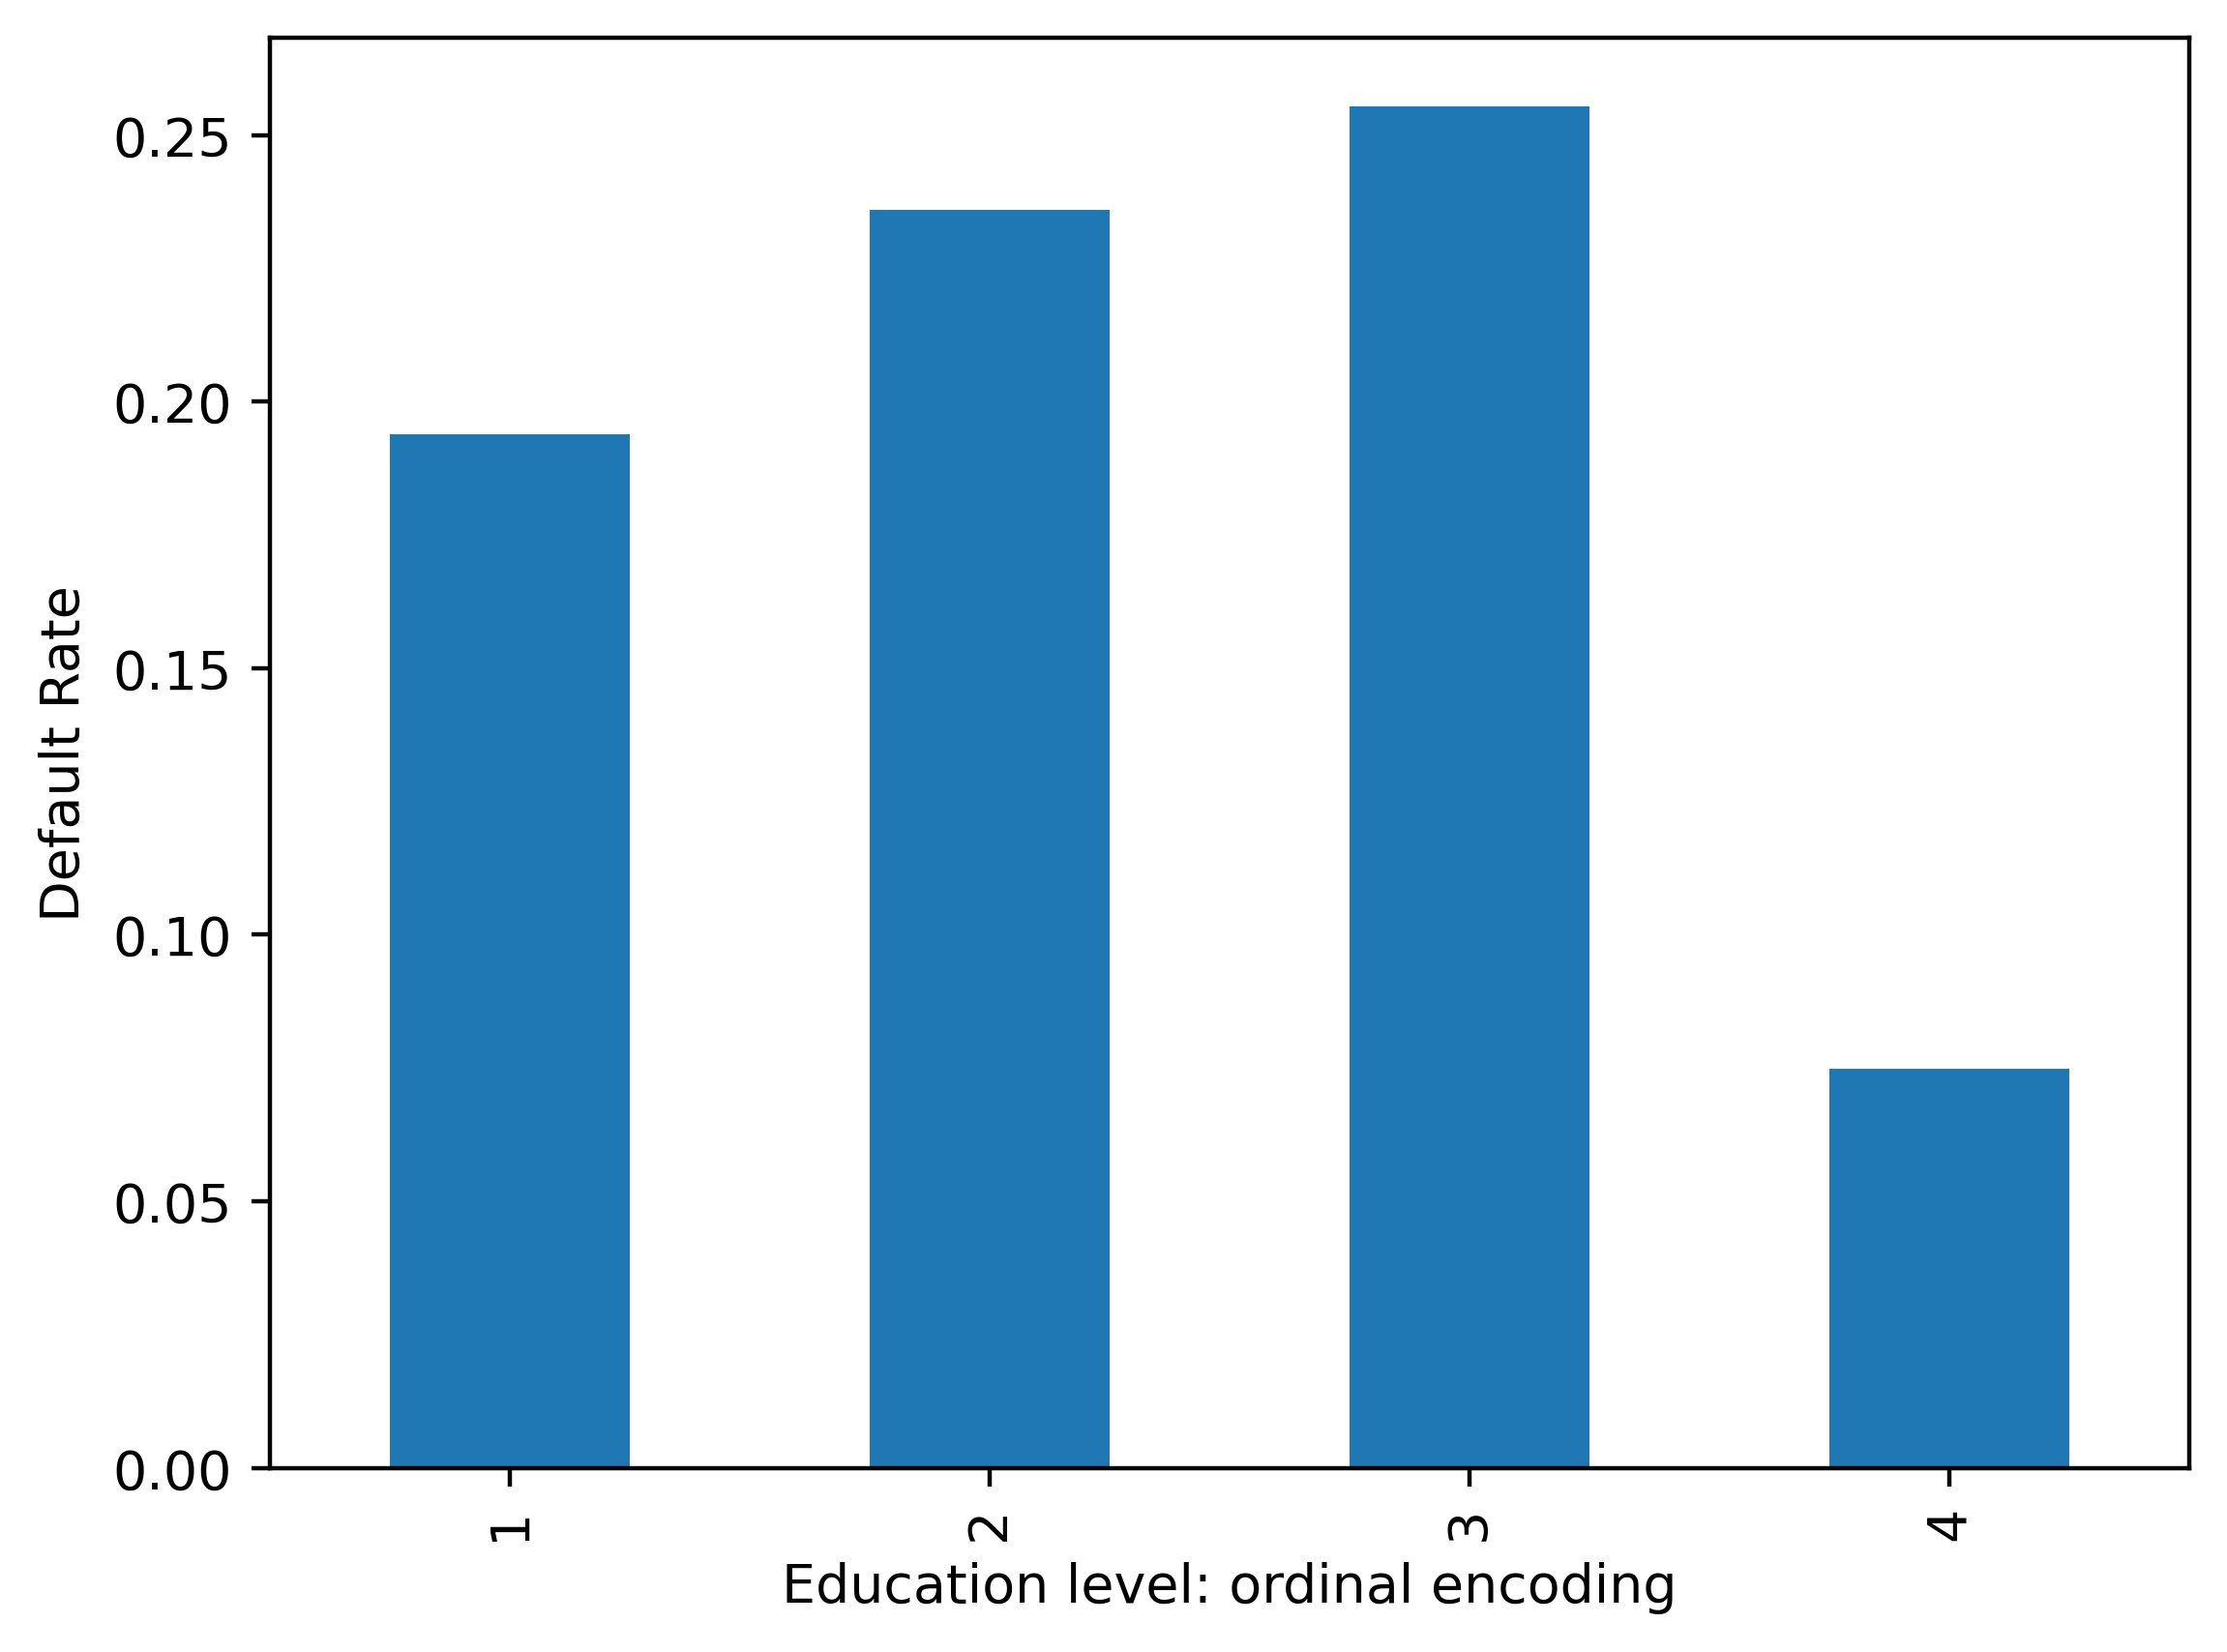

In [29]:
df_clean_2.groupby('EDUCATION').agg({'default payment next month': 'mean'}).plot.bar(legend=False)
plt.ylabel('Default Rate')
plt.xlabel('Education level: ordinal encoding')

In [30]:
df_clean_2['EDUCATION_CAT'] = 'none'

In [31]:
df_clean_2[['EDUCATION', 'EDUCATION_CAT']].head(10)

,EDUCATION,EDUCATION_CAT
0,2,none
1,2,none
2,2,none
3,2,none
4,2,none
5,1,none
6,1,none
7,2,none
8,3,none
9,3,none


In [32]:
cat_mapping = {1: 'graduate school', 2: 'university', 3: 'high school', 4: 'others'}
df_clean_2['EDUCATION_CAT'] = df_clean_2['EDUCATION'].map(cat_mapping)
df_clean_2[['EDUCATION', 'EDUCATION_CAT']].head(10)

,EDUCATION,EDUCATION_CAT
0,2,university
1,2,university
2,2,university
3,2,university
4,2,university
5,1,graduate school
6,1,graduate school
7,2,university
8,3,high school
9,3,high school


In [33]:
edu_ohe = pd.get_dummies(df_clean_2['EDUCATION_CAT'])
edu_ohe.head(10)

,graduate school,high school,others,university
0,False,False,False,True
1,False,False,False,True
2,False,False,False,True
3,False,False,False,True
4,False,False,False,True
5,True,False,False,False
6,True,False,False,False
7,False,False,False,True
8,False,True,False,False
9,False,True,False,False


In [34]:
df_with_ohe = pd.concat([df_clean_2, edu_ohe], axis=1)
df_with_ohe[['EDUCATION_CAT', 'graduate school', 'high school', 'university', 'others']].head(10)

,EDUCATION_CAT,graduate school,high school,university,others
0,university,False,False,True,False
1,university,False,False,True,False
2,university,False,False,True,False
3,university,False,False,True,False
4,university,False,False,True,False
5,graduate school,True,False,False,False
6,graduate school,True,False,False,False
7,university,False,False,True,False
8,high school,False,True,False,False
9,high school,False,True,False,False


In [35]:
df_with_ohe.to_csv('Data/Chapter_1_cleaned_data.csv', index=False)

In [36]:
df = pd.read_csv('Data/Chapter_1_cleaned_data.csv')
pay_feats = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
df[pay_feats].describe()


,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6
count,26664.000000,26664.000000,26664.000000,26664.000000,26664.000000,26664.000000
mean,-0.017777,-0.133363,-0.167679,-0.225023,-0.269764,-0.293579
std,1.126769,1.198640,1.199165,1.167897,1.131735,1.150229
min,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000
25%,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000


In [37]:
df[pay_feats[0]].value_counts().sort_index()

PAY_1
-2     2476
-1     5047
 0    13087
 1     3261
 2     2378
 3      292
 4       63
 5       23
 6       11
 7        9
 8       17
Name: count, dtype: int64

In [38]:
pay_1_bins = np.array(range(-2, 10)) - 0.5
pay_1_bins

array([-2.5, -1.5, -0.5,  0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,
        8.5])

Text(0, 0.5, 'Number of clients')

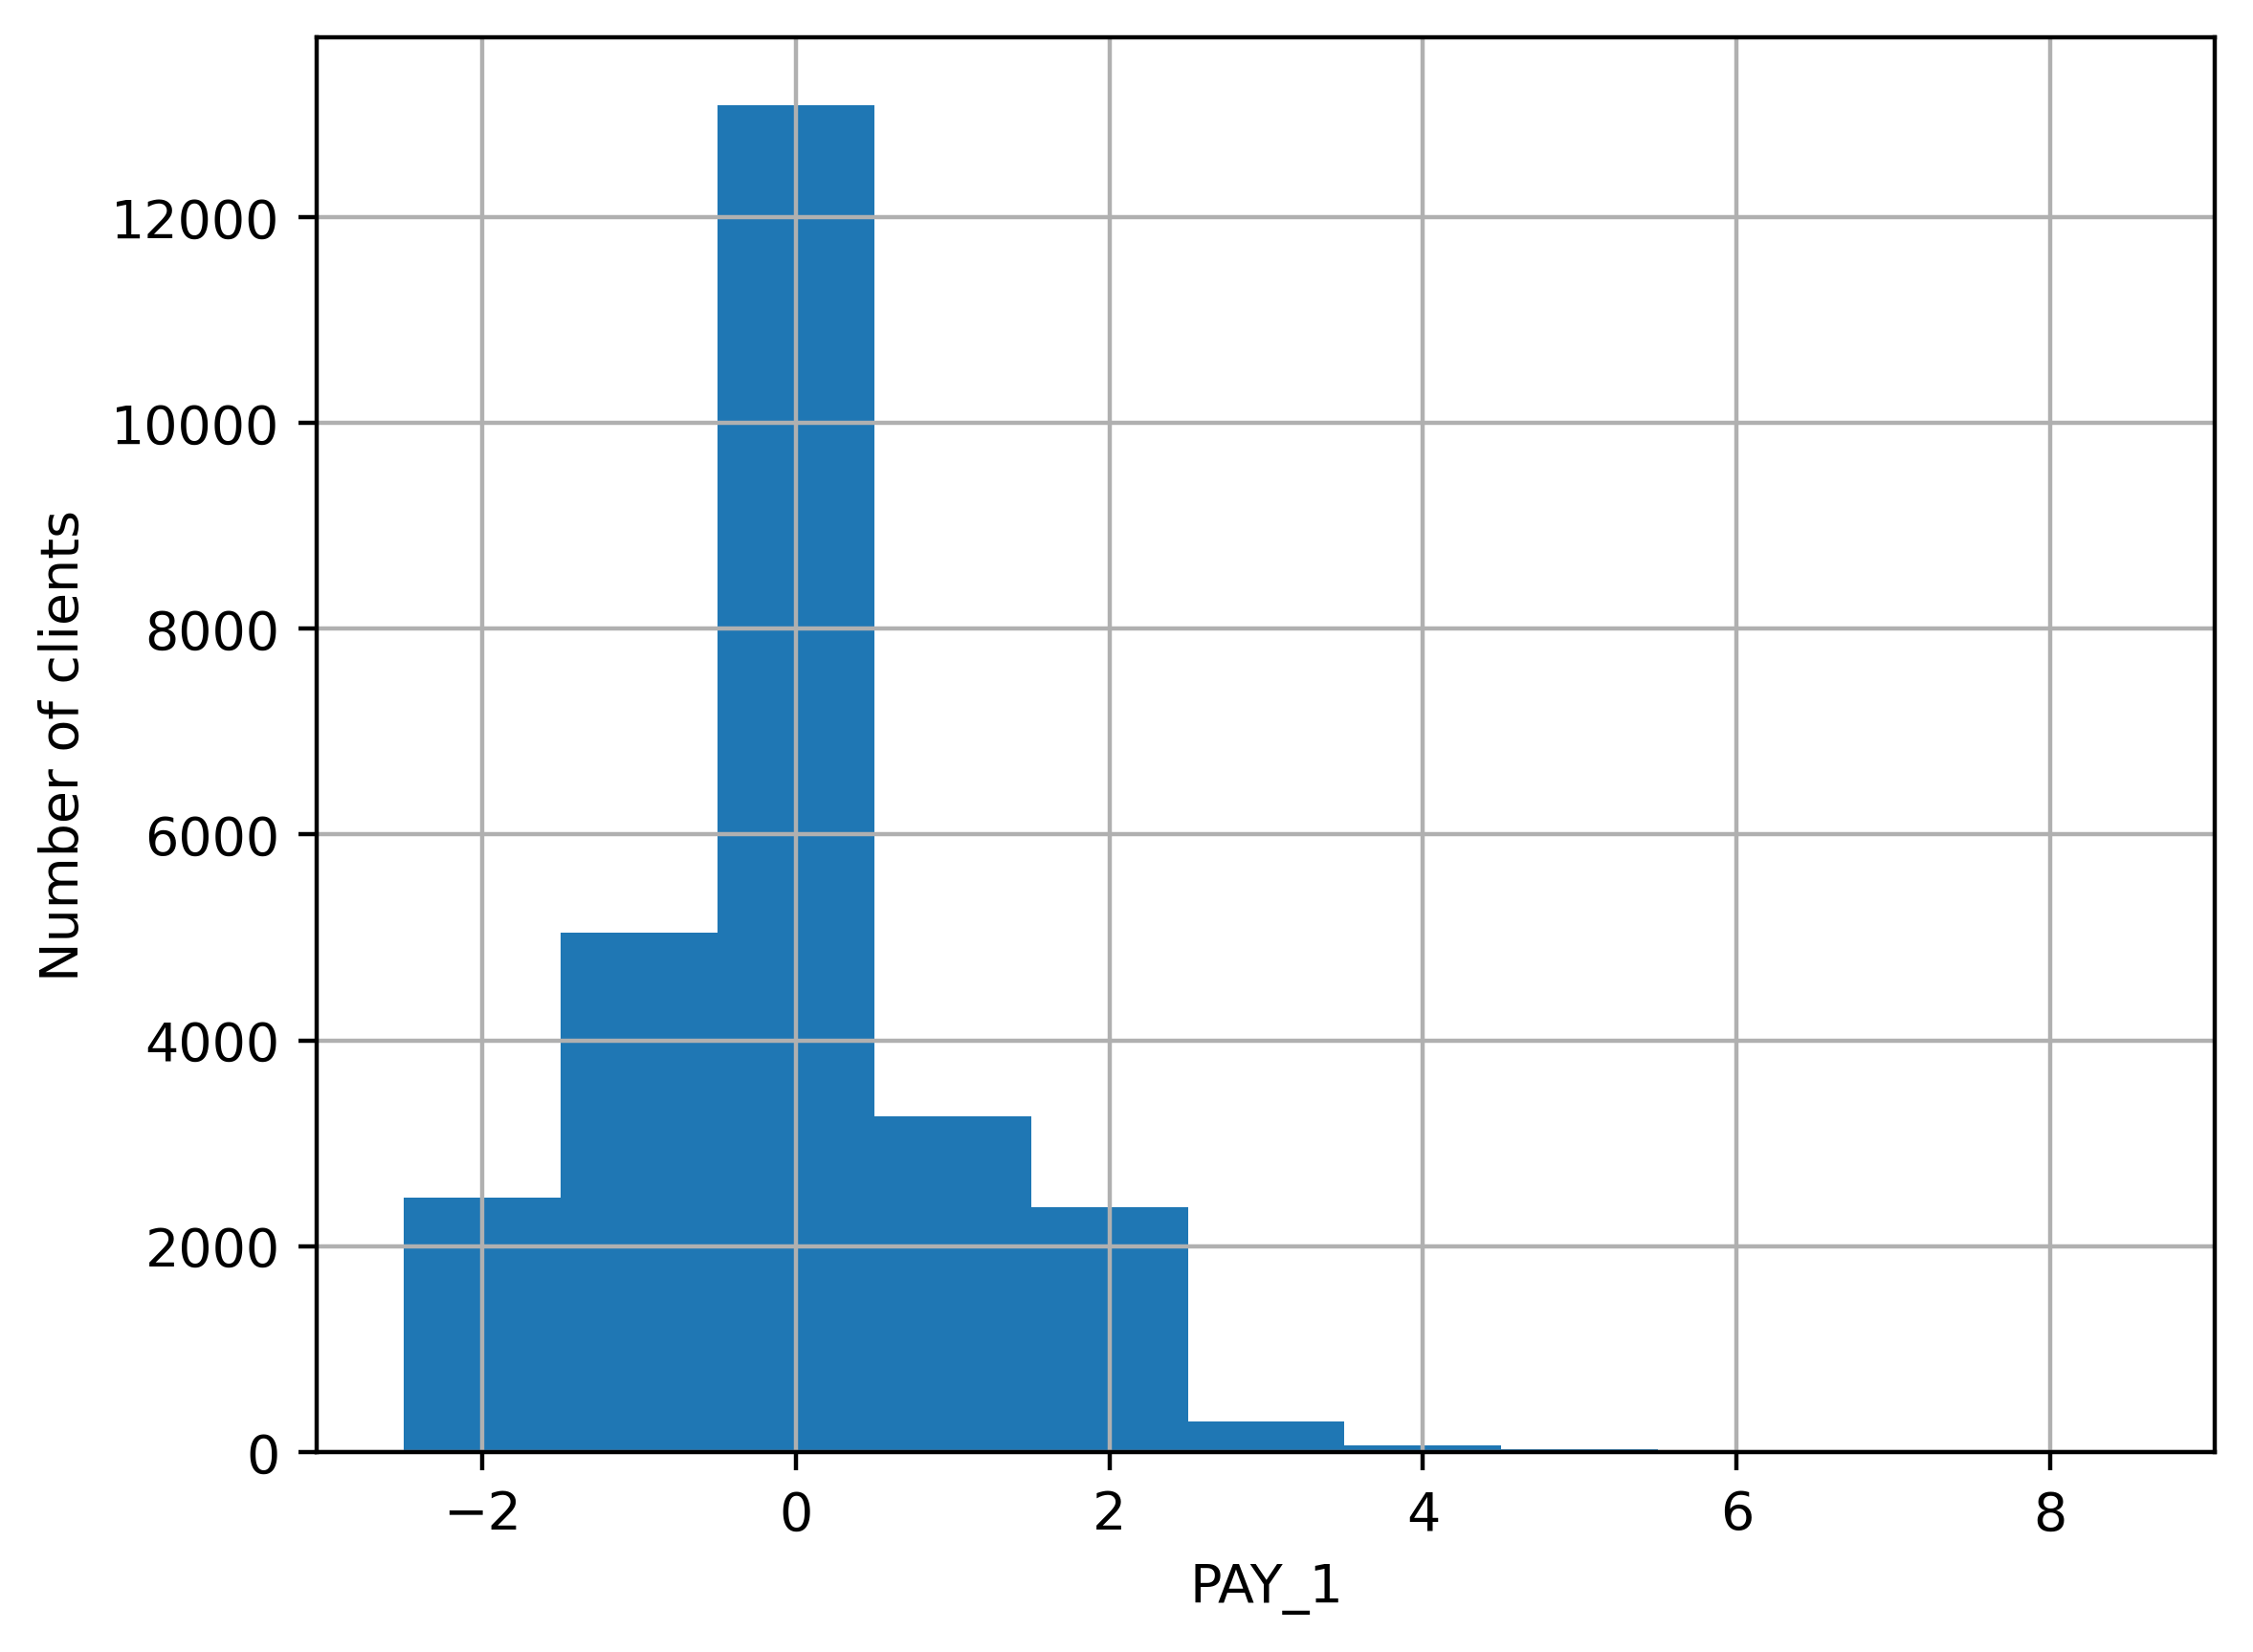

In [39]:
df[pay_feats[0]].hist(bins=pay_1_bins)
plt.xlabel('PAY_1')
plt.ylabel('Number of clients')

array([[<Axes: title={'center': 'PAY_1'}>,
        <Axes: title={'center': 'PAY_2'}>,
        <Axes: title={'center': 'PAY_3'}>],
       [<Axes: title={'center': 'PAY_4'}>,
        <Axes: title={'center': 'PAY_5'}>,
        <Axes: title={'center': 'PAY_6'}>]], dtype=object)

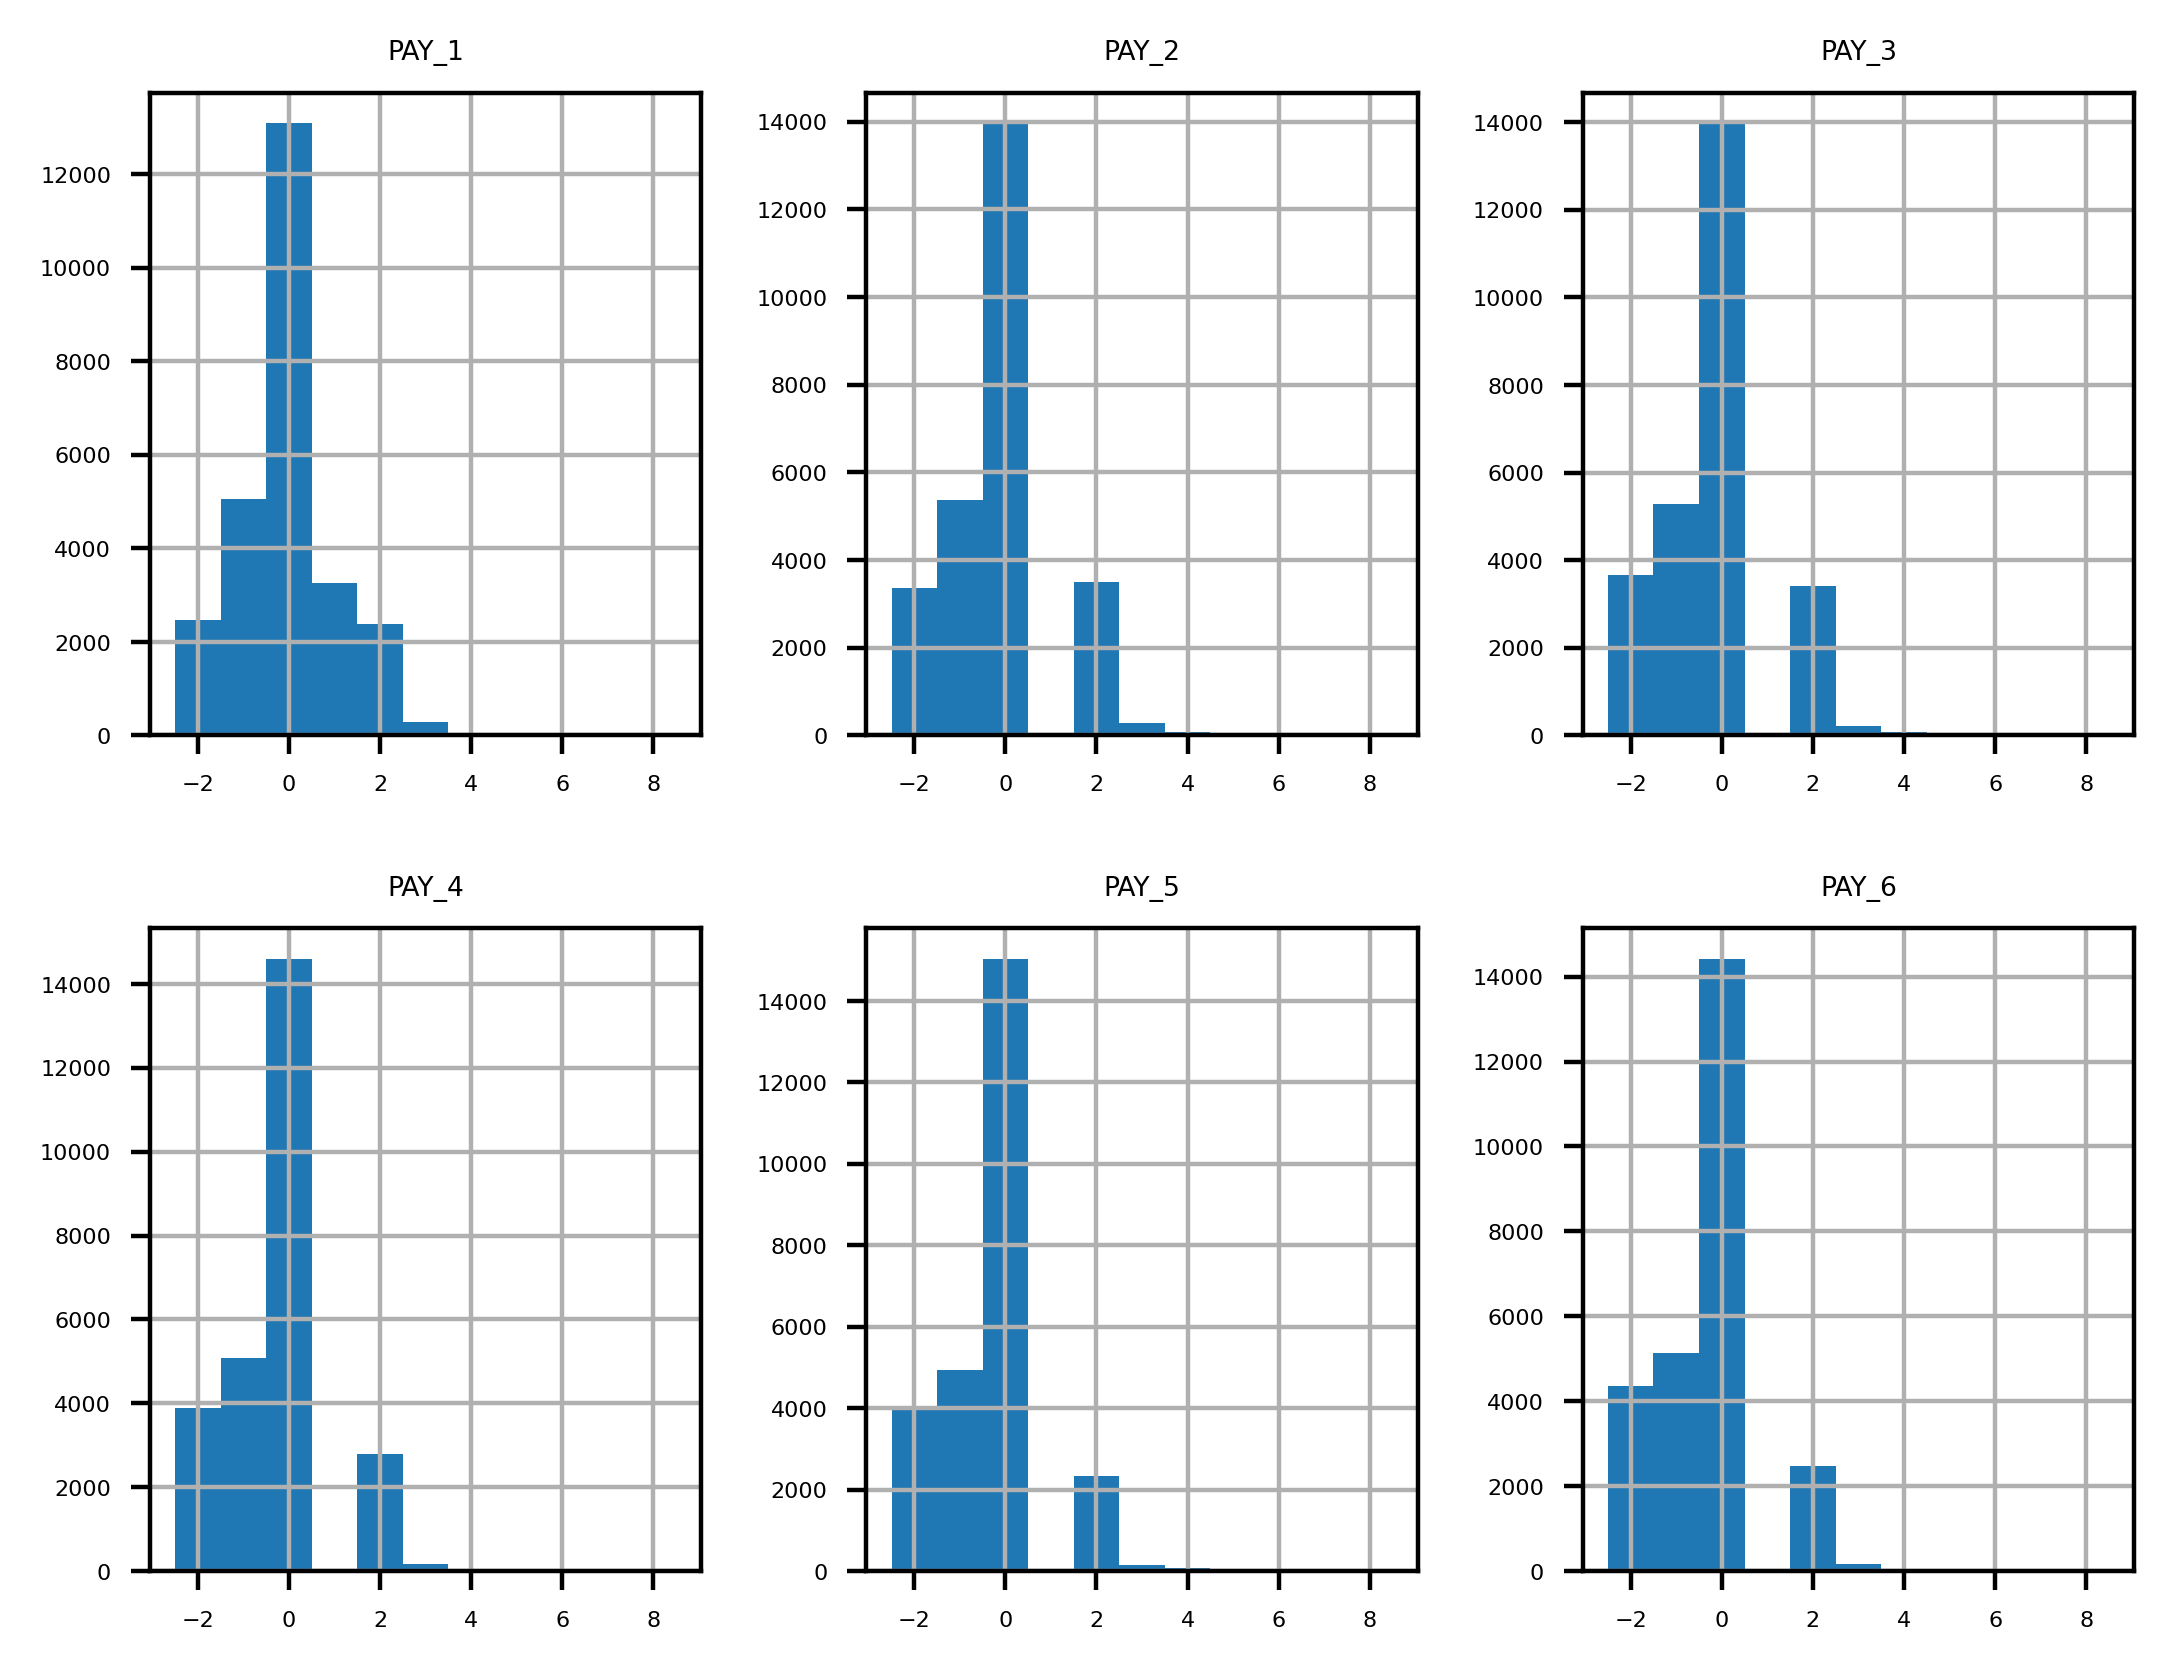

In [40]:
mpl.rcParams['font.size'] = 4
df[pay_feats].hist(bins=pay_1_bins, layout=(2, 3))

In [41]:
df.loc[df['PAY_2']==2, ['PAY_2', 'PAY_3']].head()

,PAY_2,PAY_3
0,2,-1
1,2,0
13,2,2
15,2,0
47,2,2


# Introdução ao Scikit-Learn e avaliação do modelo

objetivos do aprendizado:

- Explicar a variável de resposta
- Descrever as implicações de dados desbalanceados na classificação binária
- Dividir os dados em conjuntos de treinamento e teste
- Descrever o ajuste do modelo no scikit-learn 
- Derivar varias métricas para a classificação binária
- Criar uma curva ROC e uma curva precision-recall

In [42]:
from sklearn.linear_model import LogisticRegression

In [43]:
df = pd.read_csv('Data/Chapter_1_cleaned_data.csv')
df['default payment next month'].mean()

np.float64(0.2217971797179718)

In [44]:
df.groupby('default payment next month')['ID'].count()

default payment next month
0    20750
1     5914
Name: ID, dtype: int64

In [45]:
# selecionar o modelo e instancia-lo a partir da classe fornecida pelo scikit-learn
my_new_lr = LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True, intercept_scaling=1, max_iter=100,
                           n_jobs=None, penalty='l2', random_state=None, solver='liblinear', tol=0.0001,
                           verbose=0, warm_start=False)
my_new_lr

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [46]:
my_new_lr.C = 0.1
my_new_lr.solver = 'liblinear'
my_new_lr

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.1
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [47]:
#tomando emprestadas do dataset as 10 primeiras amostras de uma unica característica
X = df['EDUCATION'][0:10].values.reshape(-1, 1)
X

array([[2],
       [2],
       [2],
       [2],
       [2],
       [1],
       [1],
       [2],
       [3],
       [3]])

In [48]:
y = df['default payment next month'][0:10].values
y

array([1, 1, 0, 0, 0, 0, 0, 0, 0, 0])

In [49]:
my_new_lr.fit(X, y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,0.1
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [50]:
#já conseguimos utyilizar o modelo treinado para fazer previsões, iremos prever as 10 proximas linhas da característica EDUCATION
new_X = df['EDUCATION'][10:20].values.reshape(-1, 1)
new_X

array([[3],
       [1],
       [2],
       [2],
       [1],
       [3],
       [1],
       [1],
       [1],
       [3]])

In [51]:
# as previsões são feitas utilizando o método predict, iremos prever o y agora
my_new_lr.predict(new_X)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [52]:
#rotulos reais correspondentes
df['default payment next month'][10:20].values

array([0, 0, 0, 1, 0, 0, 1, 0, 0, 0])

Gerando dados sintéticos

In [53]:
#Gerando dados aleatórios
np.random.seed(seed=1)
X = np.random.uniform(low=0.0, high=10.0, size=(1000,))
X[0:10]

array([4.17022005e+00, 7.20324493e+00, 1.14374817e-03, 3.02332573e+00,
       1.46755891e+00, 9.23385948e-01, 1.86260211e+00, 3.45560727e+00,
       3.96767474e+00, 5.38816734e+00])

Dados para uma regressão linear simples

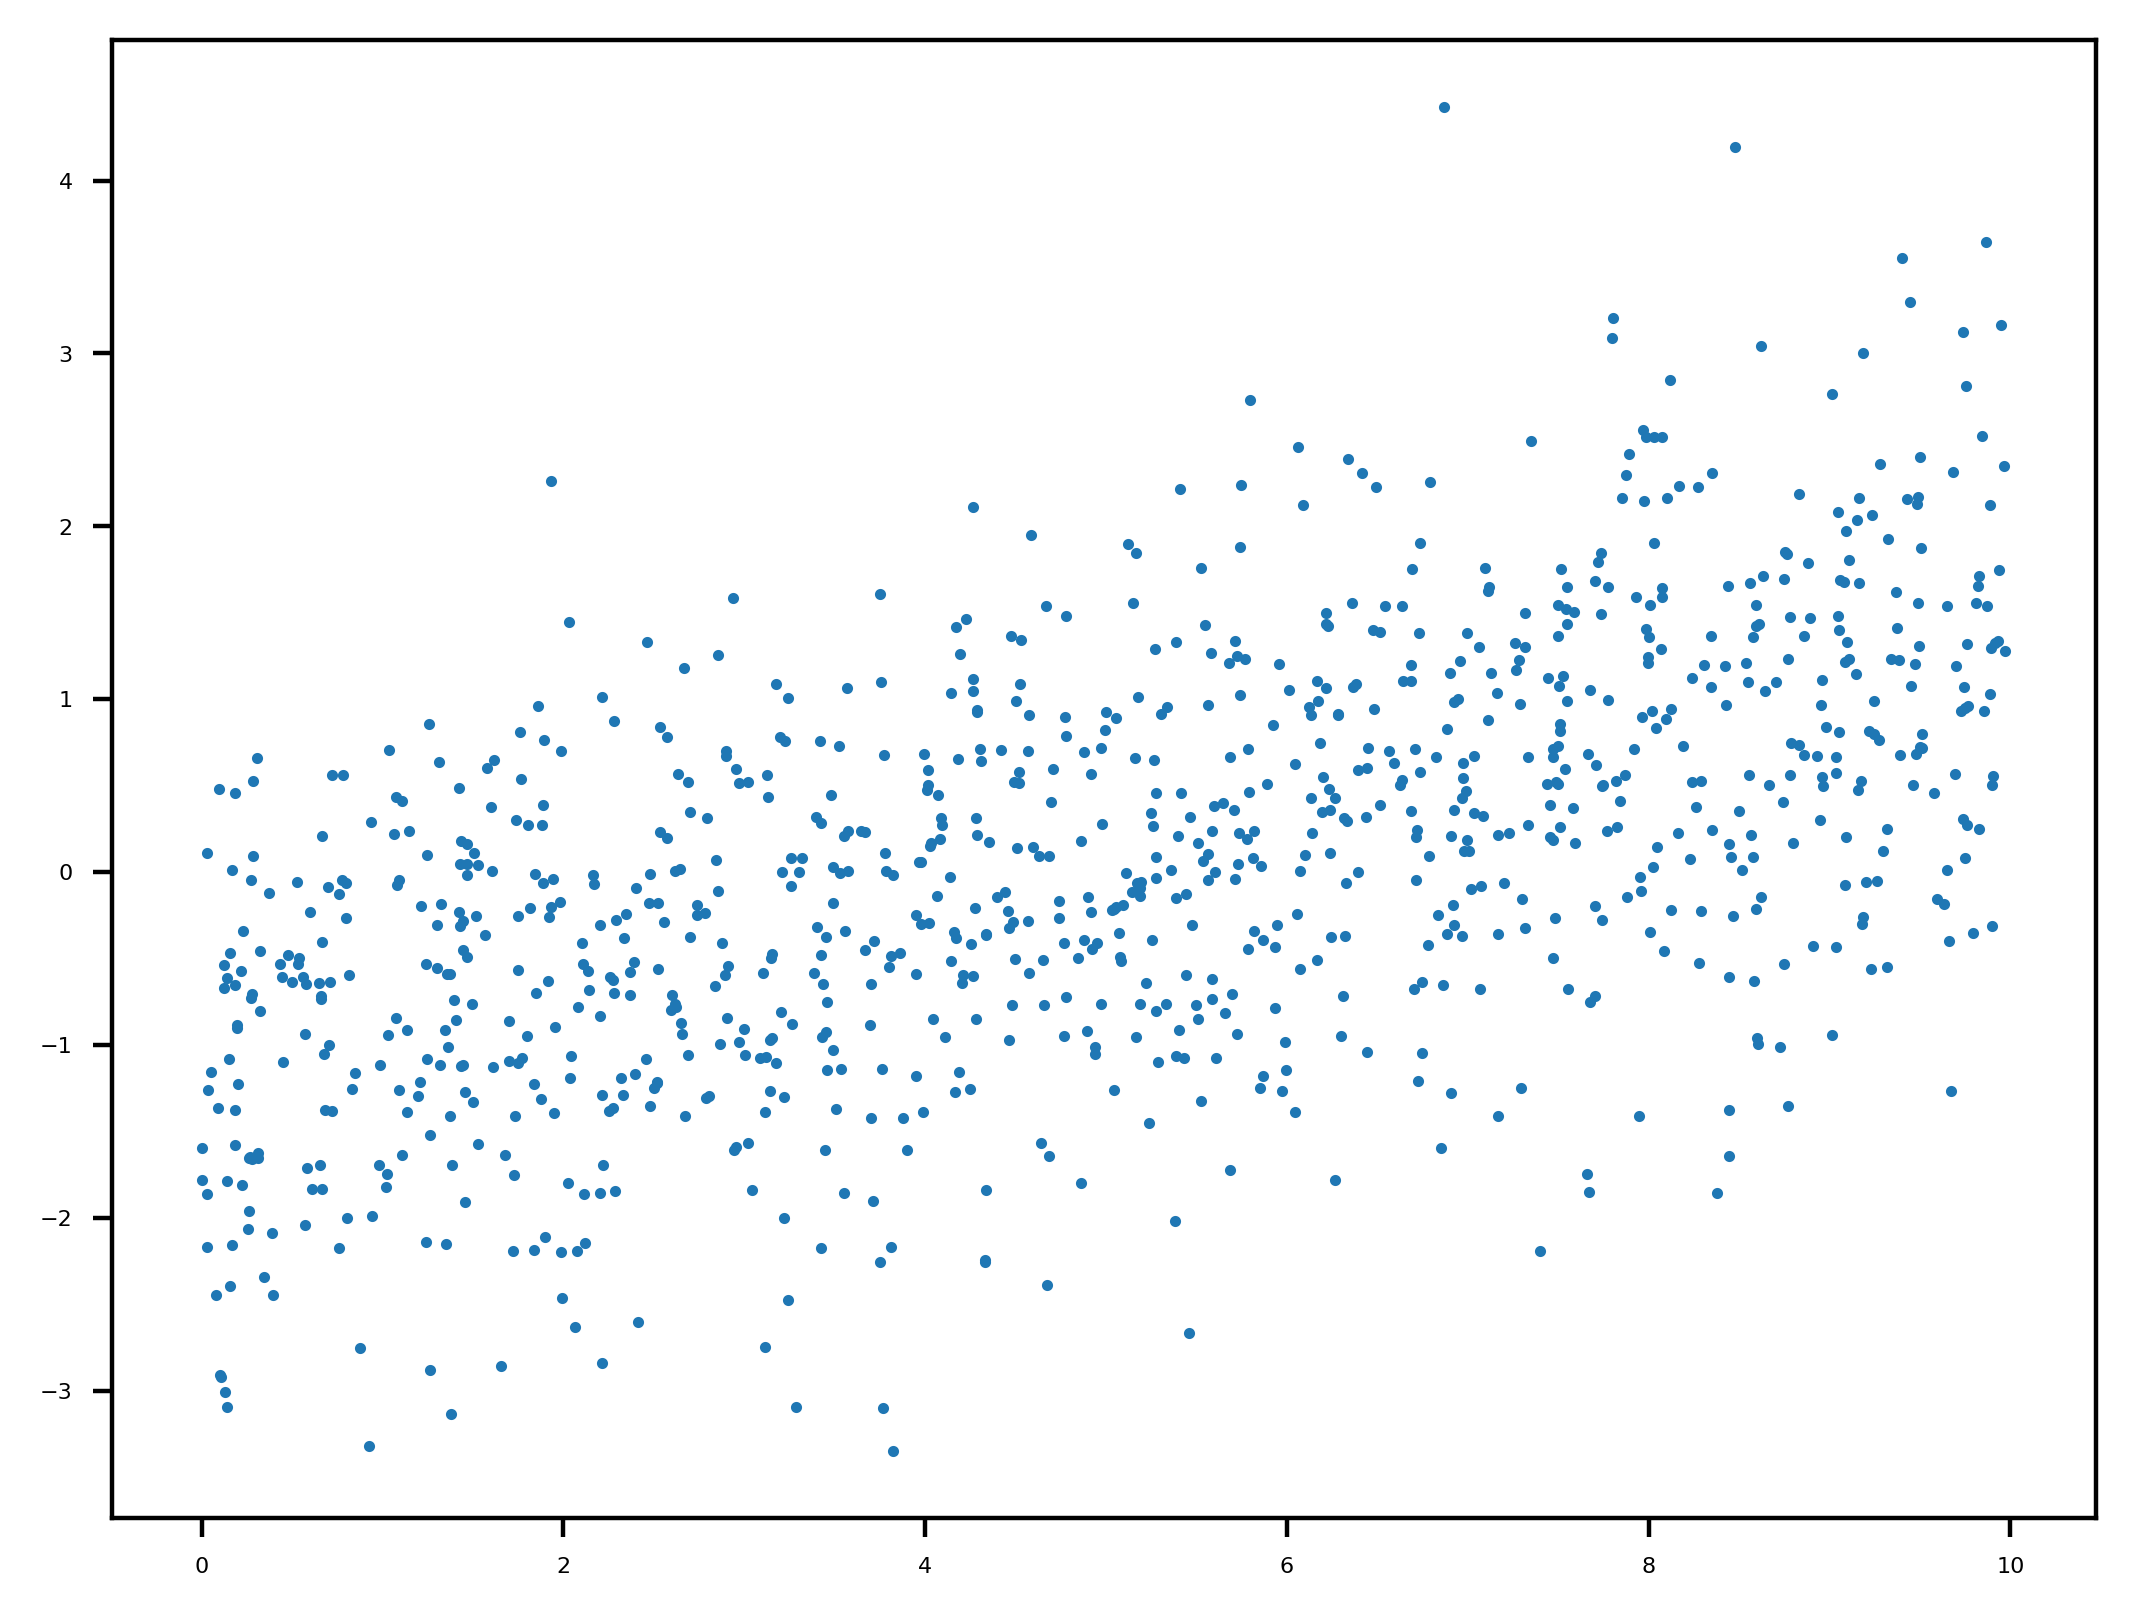

In [54]:
#1. definir o seed aleatorio
np.random.seed(seed=1)

#2. declarar variaveis para a inclinacao e a interceptacao de nossos dados lineares
slope = 0.25
intercept = -1.25

#3.criar a variavel de resposta usando a equacao familiar de uma linha, com o acrescimo de um ruido gaussiano
y = slope * X + np.random.normal(loc=0.0, scale=1.0, size=(1000,)) + intercept

#4. plotar os dados
mpl.rcParams['figure.dpi'] = 400
plt.scatter(X, y, s=1)

Regressao linear com o scikit-learn

In [55]:
#1. importar a classe LinearRegression do modulo linear_model do scikit-learn
from sklearn.linear_model import LinearRegression
#2. instanciar a classe LinearRegression
lin_reg = LinearRegression()
lin_reg

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [56]:
#1. ajustar o modelo usando nossos dados sinteticos, lembrando de redimensionar o array de características. Para que as amostras fiquem ao longo
#da primeira dimensão
lin_reg.fit(X.reshape(-1, 1), y)
#2. examinar lin_reg.intercept_ e lin_reg.coef_ que contem, respectivamente, a interceptação e o coeficiente (inclinação) da linha ajustada
print(lin_reg.intercept_)
print(lin_reg.coef_)

-1.1612566002825888
[0.24002588]


In [57]:
#fazer as previsões
y_pred = lin_reg.predict(X.reshape(-1, 1))
y_pred[0:10]

array([-0.16029588,  0.56770858, -1.16098207, -0.43558019, -0.80900449,
       -0.93962008, -0.7141839 , -0.33182144, -0.20891199,  0.13204299])

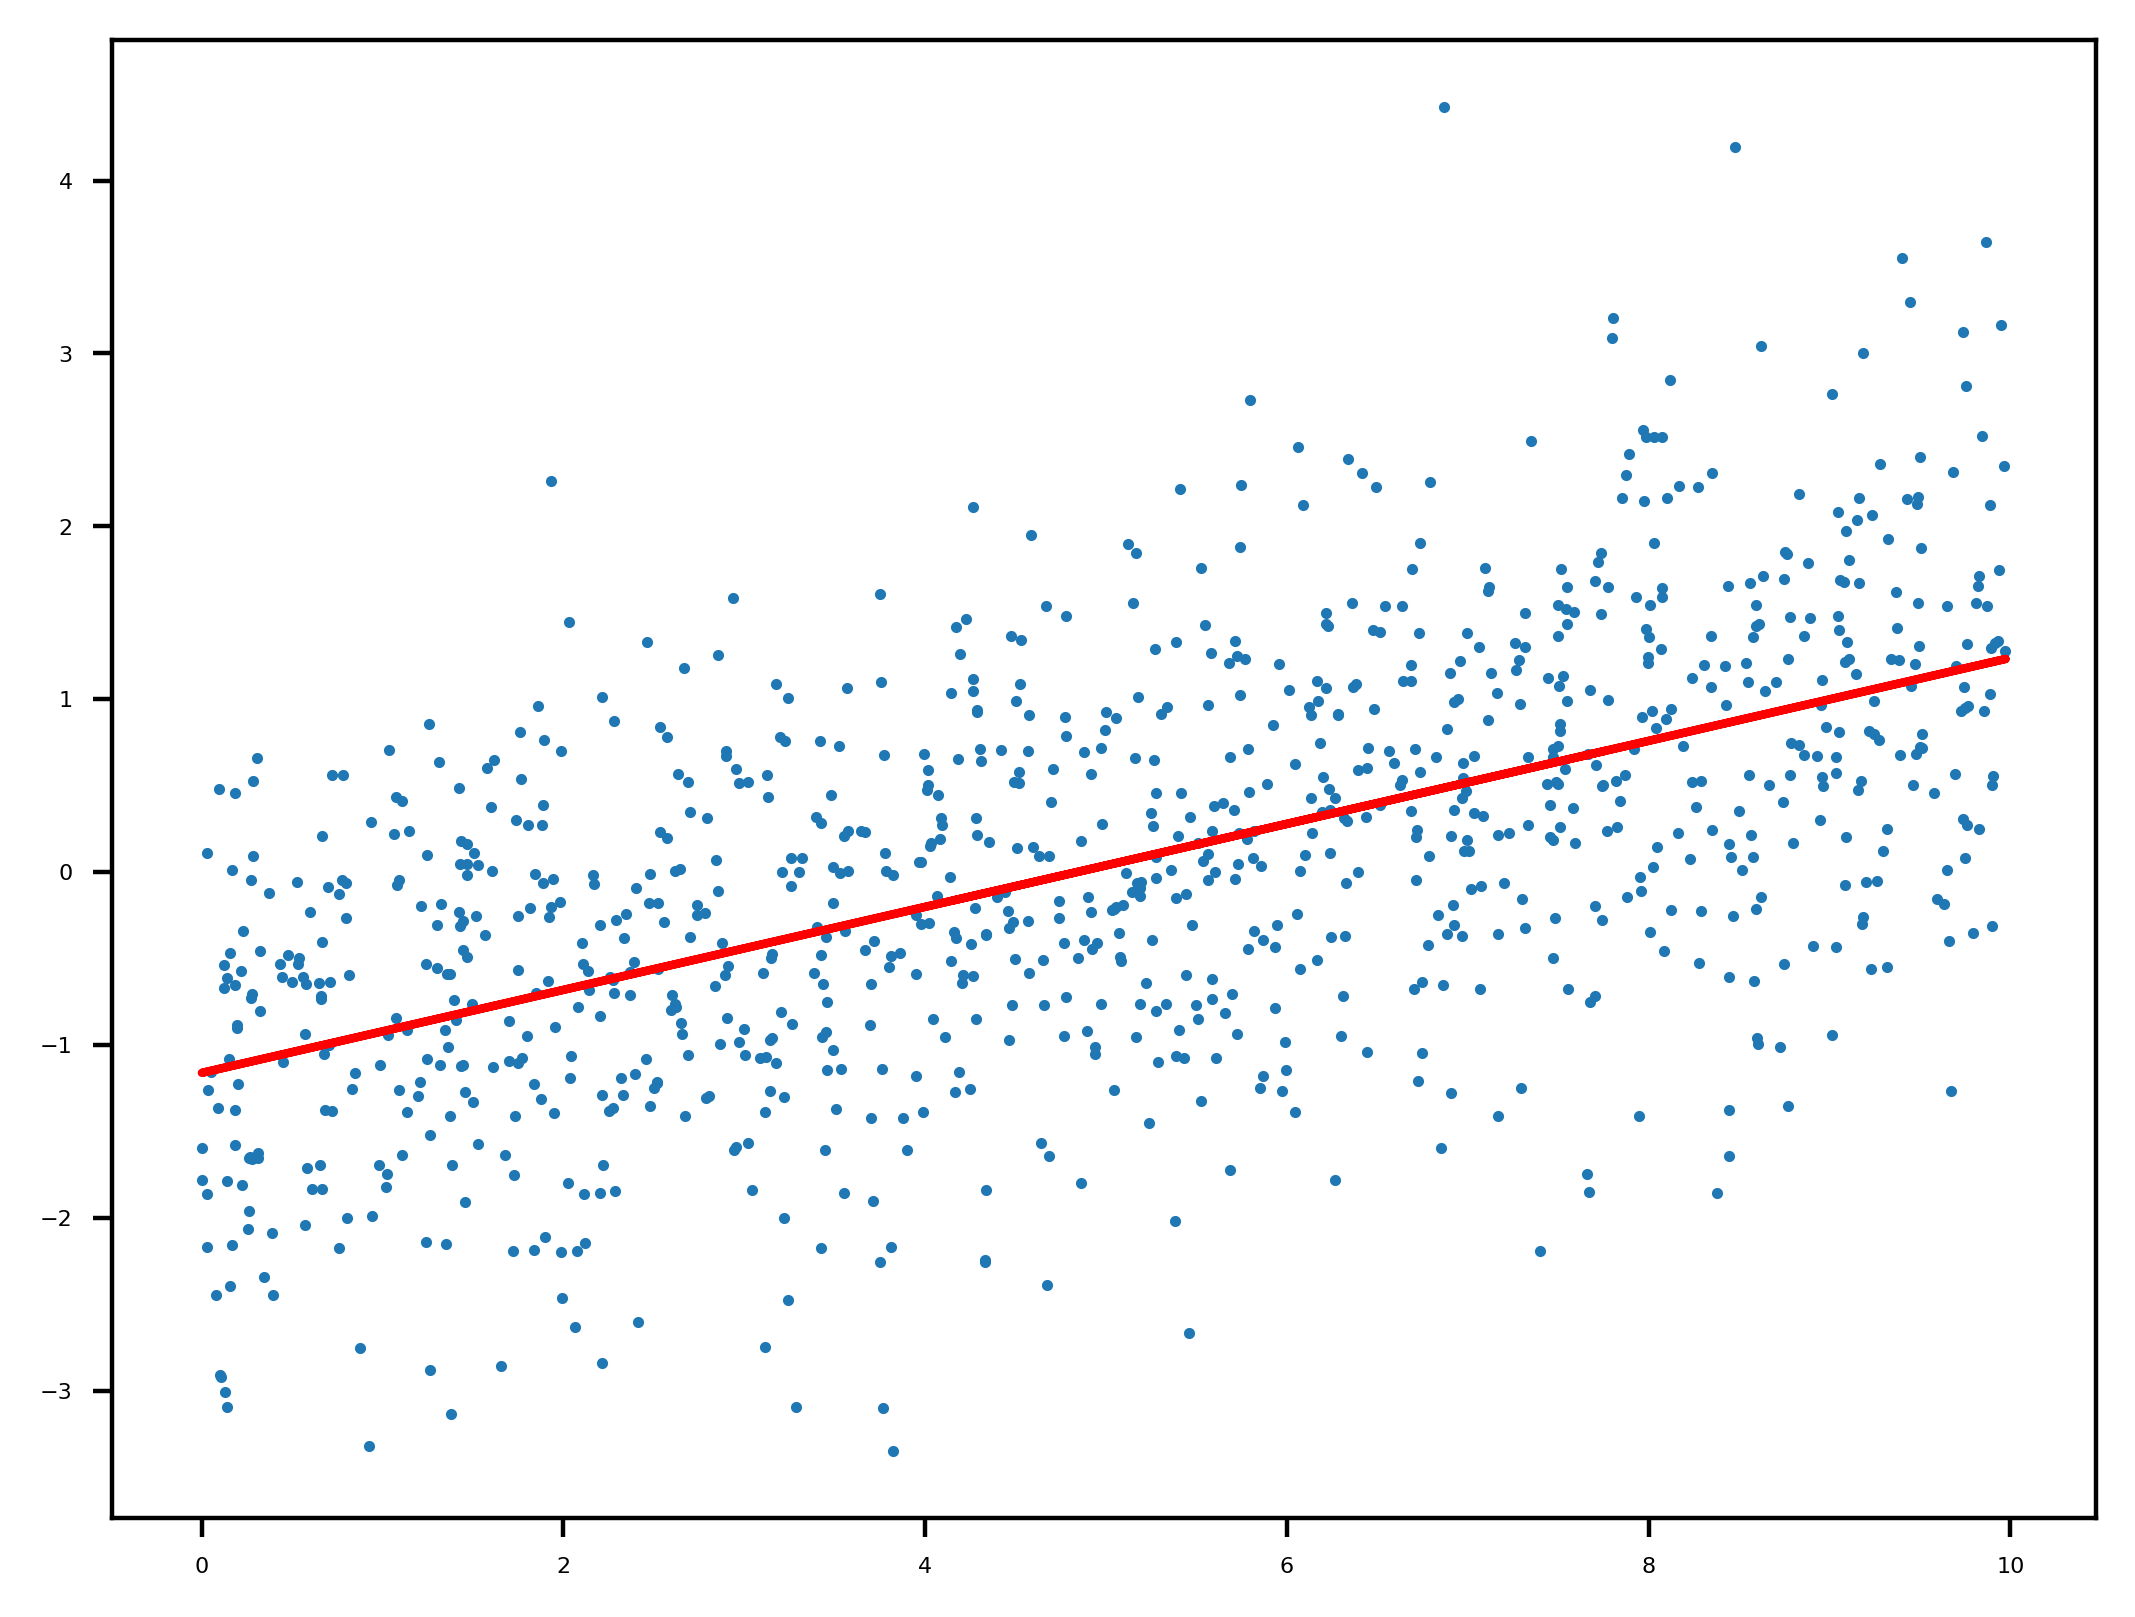

In [58]:
plt.scatter(X, y, s=1)
plt.plot(X, y_pred, 'r')

Enquanto no caso atual estamos vendo como o modelo "ajusta" os mesmos dados com os quais foi treinado, enteriormente examinamos previsoes do modelo para dados novos e desconhecidos, em ML geralmente o que nos interessa sao os recursos preditivos. No entanto, no fim das contas as previsoes tanto dos dados de treinamento usados para ajustar o modelo, quanto dos dados de teste, que nao foram usados no ajuste, sao importantes para entendermos o funcionamento do modelo.

Metricas de desempenho de modelos para a classificacao binaria

In [59]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df['EDUCATION'].values.reshape(-1, 1), df['default payment next month'].values, test_size=0.2, random_state=24)
X_train.shape, X_test.shape, y_train.shape, y_test.shape


((21331, 1), (5333, 1), (21331,), (5333,))

In [60]:
#verificar se a fração de positivos e negativos é aproximadamente a mesma em ambos os conjuntos
np.mean(y_train), np.mean(y_test)

(np.float64(0.223102526838873), np.float64(0.21657603600225014))

acurarica da classificacao

In [61]:
from sklearn.linear_model import LogisticRegression

example_lr = LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True, intercept_scaling=1, max_iter=100,
                           n_jobs=None, penalty='l2', random_state=None, solver='liblinear', tol=0.0001,
                           verbose=0, warm_start=False)
example_lr.fit(X_train, y_train)
y_pred = example_lr.predict(X_test)
y_pred[0:10]   

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [62]:
#Acurarica da classificacao
is_correct = y_pred == y_test
np.mean(is_correct)

np.float64(0.7834239639977498)

In [63]:
#outras formas de calcular a acuracia
example_lr.score(X_test, y_test)

0.7834239639977498

In [64]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.7834239639977498

In [65]:
P = sum(y_test)
P

np.int64(1155)

In [66]:
TP = sum((y_test == 1) & (y_pred == 1))
TP

np.int64(0)

In [67]:
TPR = TP / P
TPR

np.float64(0.0)

In [68]:
FN = sum((y_test == 1) & (y_pred == 0))
FN

np.int64(1155)

In [69]:
FNR = FN / P
FNR

np.float64(1.0)

In [70]:
N = sum(y_test == 0)
N

np.int64(4178)

In [71]:
TN = sum((y_test == 0) & (y_pred == 0))
TN

np.int64(4178)

In [72]:
FP = sum((y_test == 0) & (y_pred == 1))
FP

np.int64(0)

In [73]:
TNR = TN / N
FPR = FP / N
print('the true negative rate is {} and the false positive rate is {}'.format(TNR, FPR))

the true negative rate is 1.0 and the false positive rate is 0.0


In [74]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred)

array([[4178,    0],
       [1155,    0]])

In [75]:
#Obtendo probabilidade previstas a partir de um modelo de regressao logistica
y_pred_proba = example_lr.predict_proba(X_test)
y_pred_proba

array([[0.77456295, 0.22543705],
       [0.77456295, 0.22543705],
       [0.79016179, 0.20983821],
       ...,
       [0.79016179, 0.20983821],
       [0.79016179, 0.20983821],
       [0.79016179, 0.20983821]], shape=(5333, 2))

In [76]:
prob_sum = np.sum(y_pred_proba, axis=1)
prob_sum

array([1., 1., 1., ..., 1., 1., 1.], shape=(5333,))

In [77]:
np.unique(prob_sum)

array([1.])

In [78]:
pos_proba = y_pred_proba[:, 1]
pos_proba

array([0.22543705, 0.22543705, 0.20983821, ..., 0.20983821, 0.20983821,
       0.20983821], shape=(5333,))

(array([1883.,    0.,    0., 2519.,    0.,    0.,  849.,    0.,    0.,
          82.]),
 array([0.20983821, 0.21475824, 0.21967826, 0.22459829, 0.22951831,
        0.23443834, 0.23935837, 0.24427839, 0.24919842, 0.25411844,
        0.25903847]),
 <BarContainer object of 10 artists>)

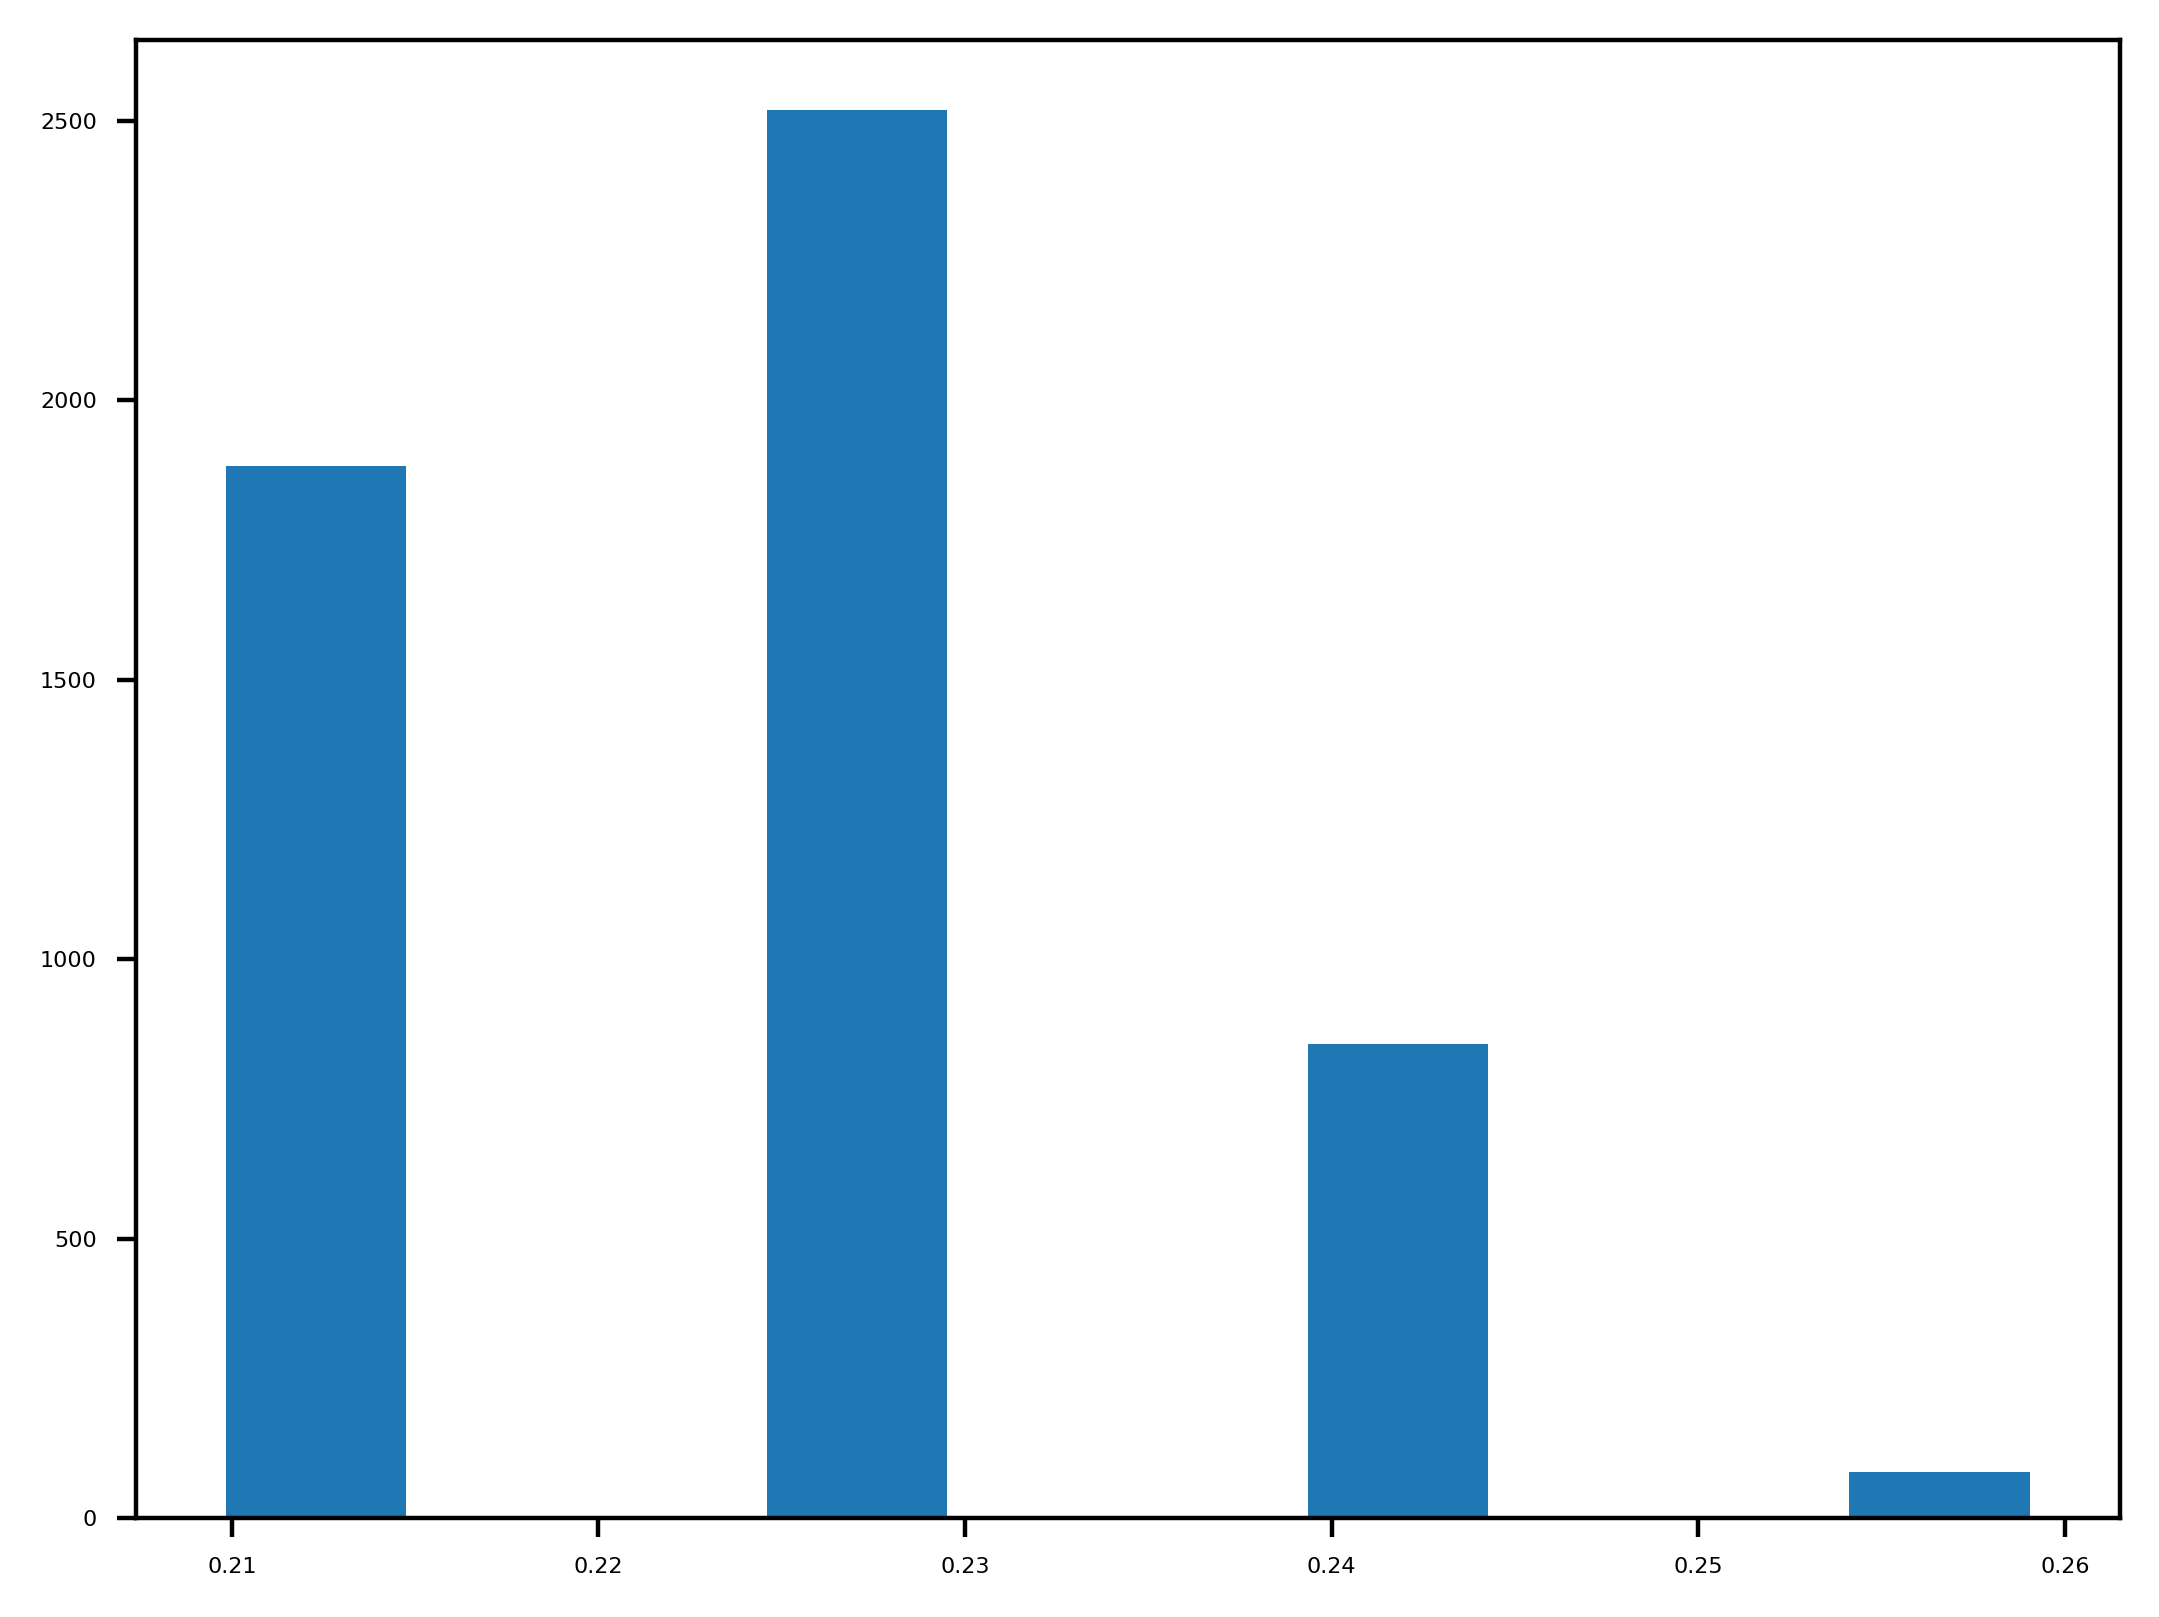

In [79]:
plt.hist(pos_proba)

Text(0, 0.5, 'Number of clients')

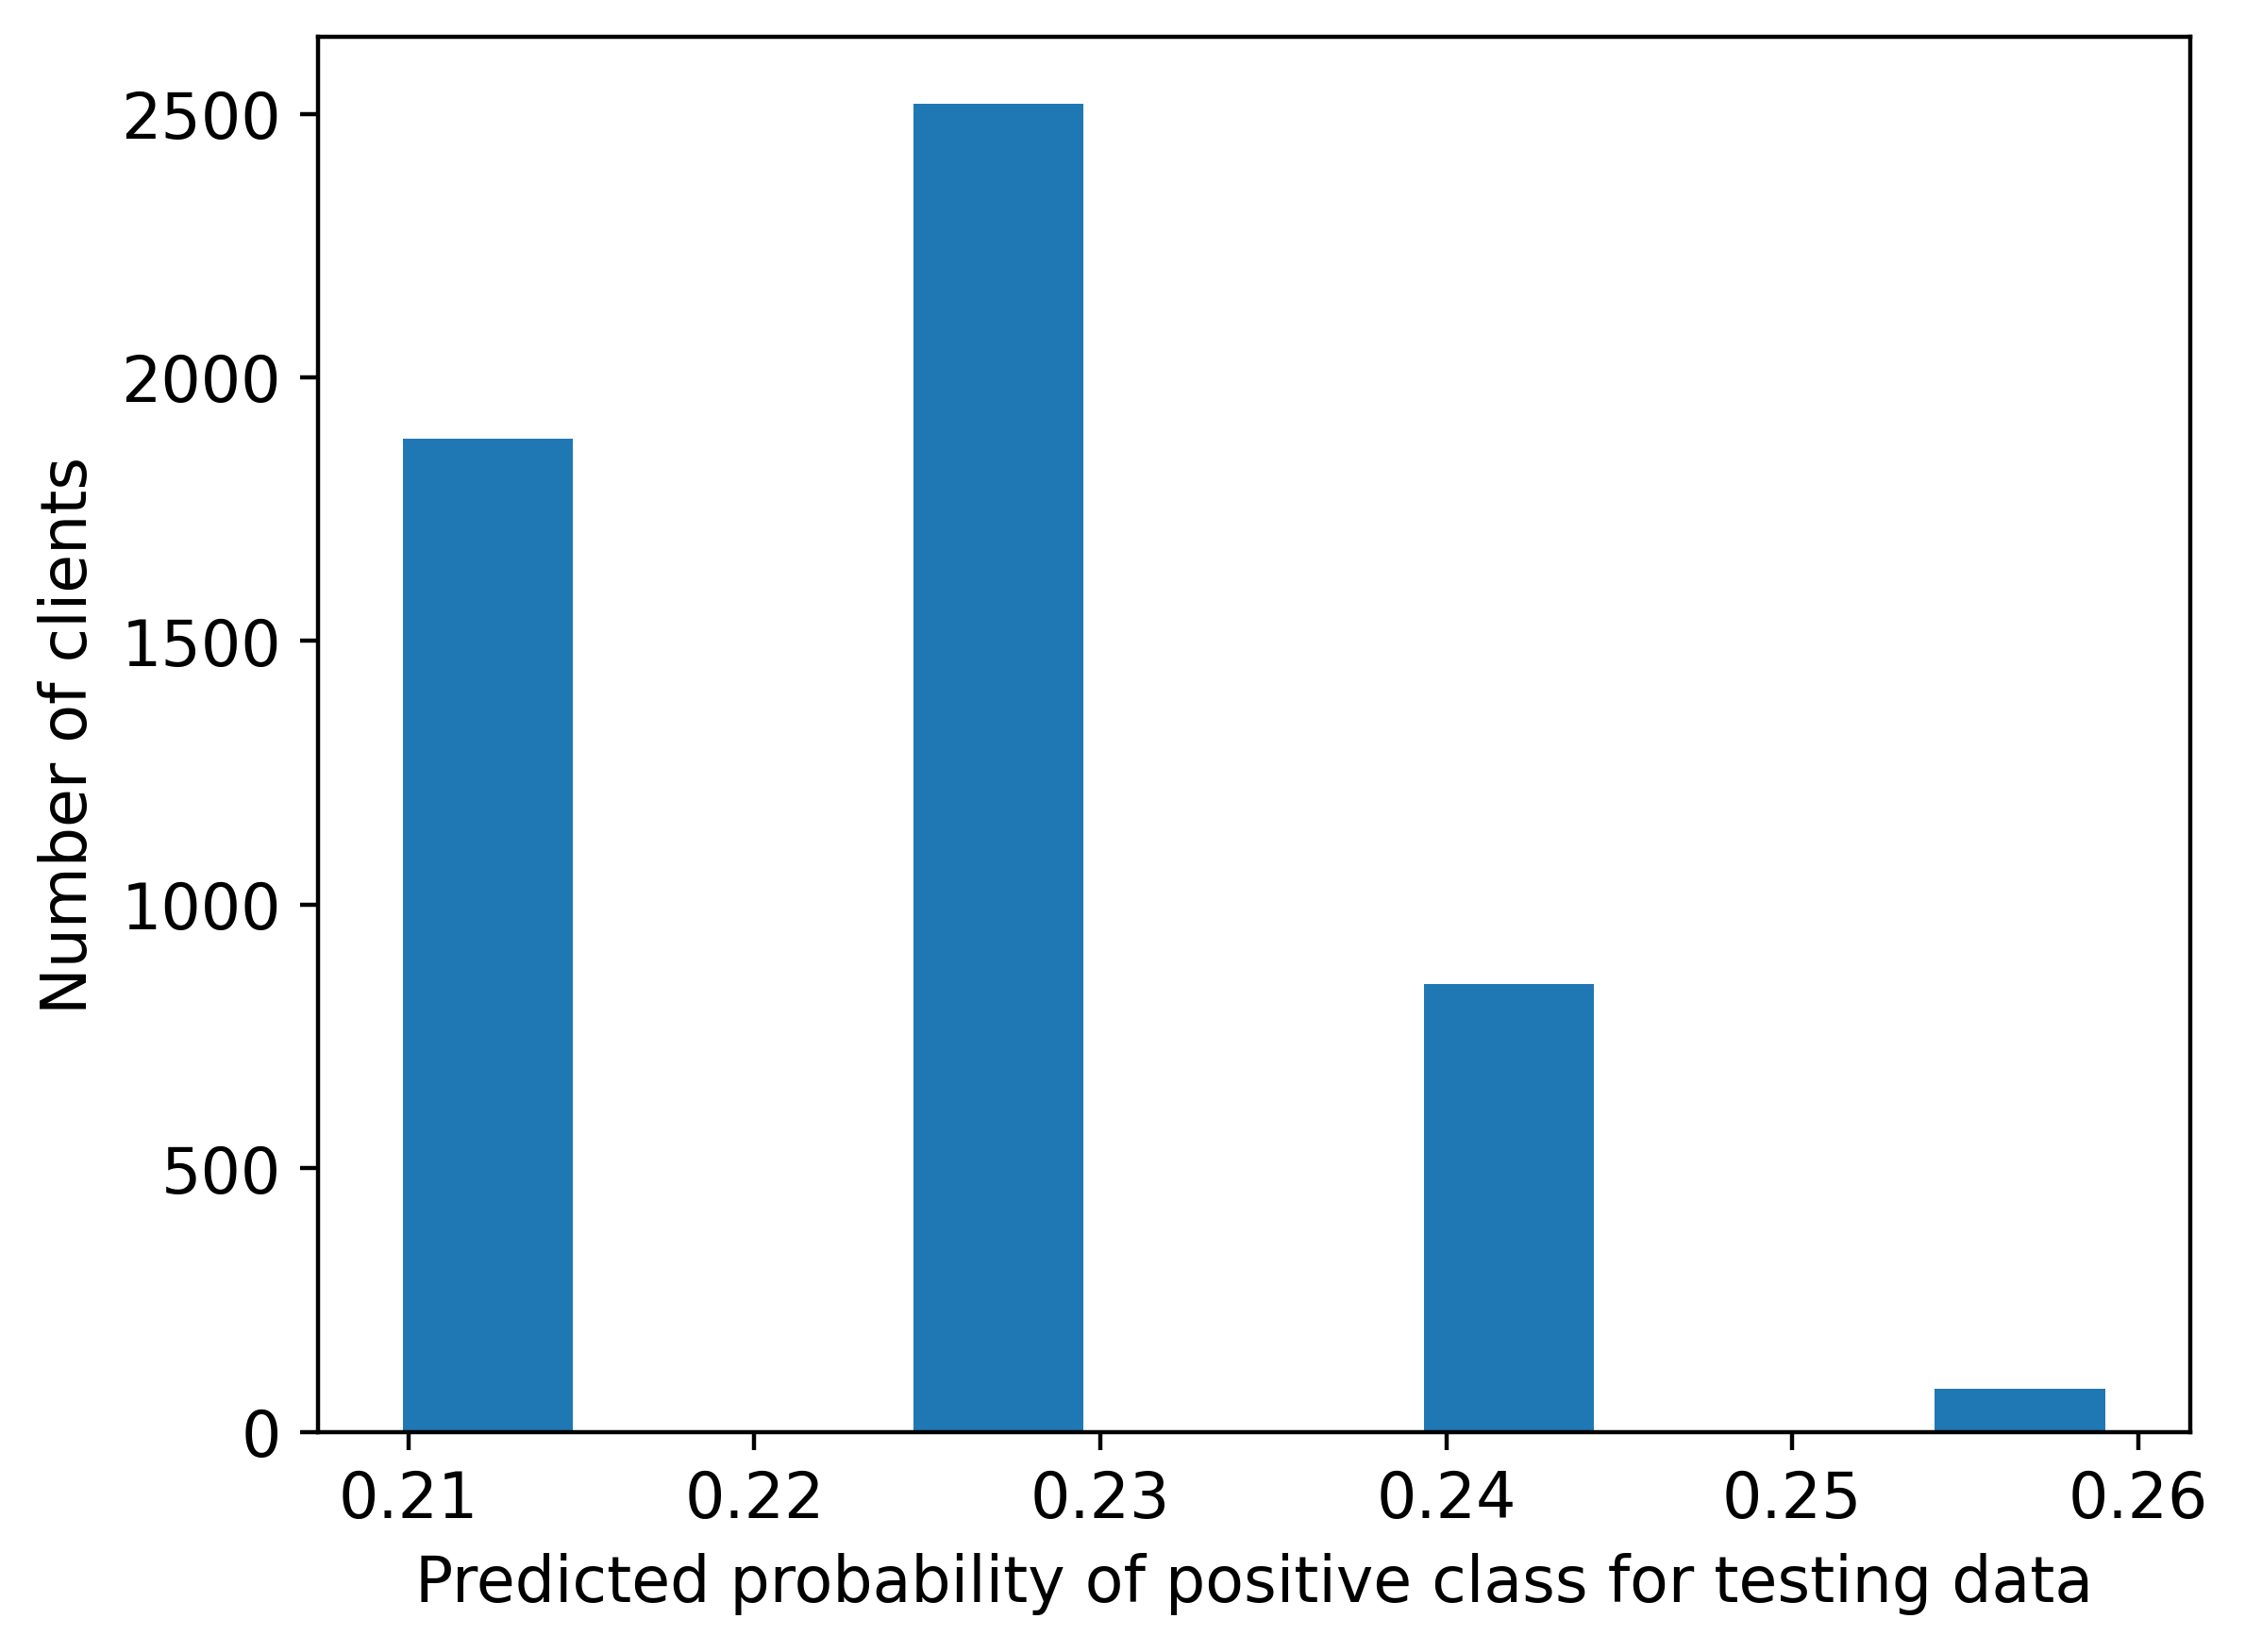

In [80]:
mpl.rcParams['font.size'] = 12
plt.hist(pos_proba)
plt.xlabel('Predicted probability of positive class for testing data')
plt.ylabel('Number of clients')

In [81]:
#Dividindo as probabilidades previstas em duas amostras, uma contendo apenas amostras positivas e outra apenas amostras negativas
pos_sample_pos_proba = pos_proba[y_test == 1]
neg_sample_pos_proba = pos_proba[y_test == 0]

Text(0, 0.5, 'Number of clients')

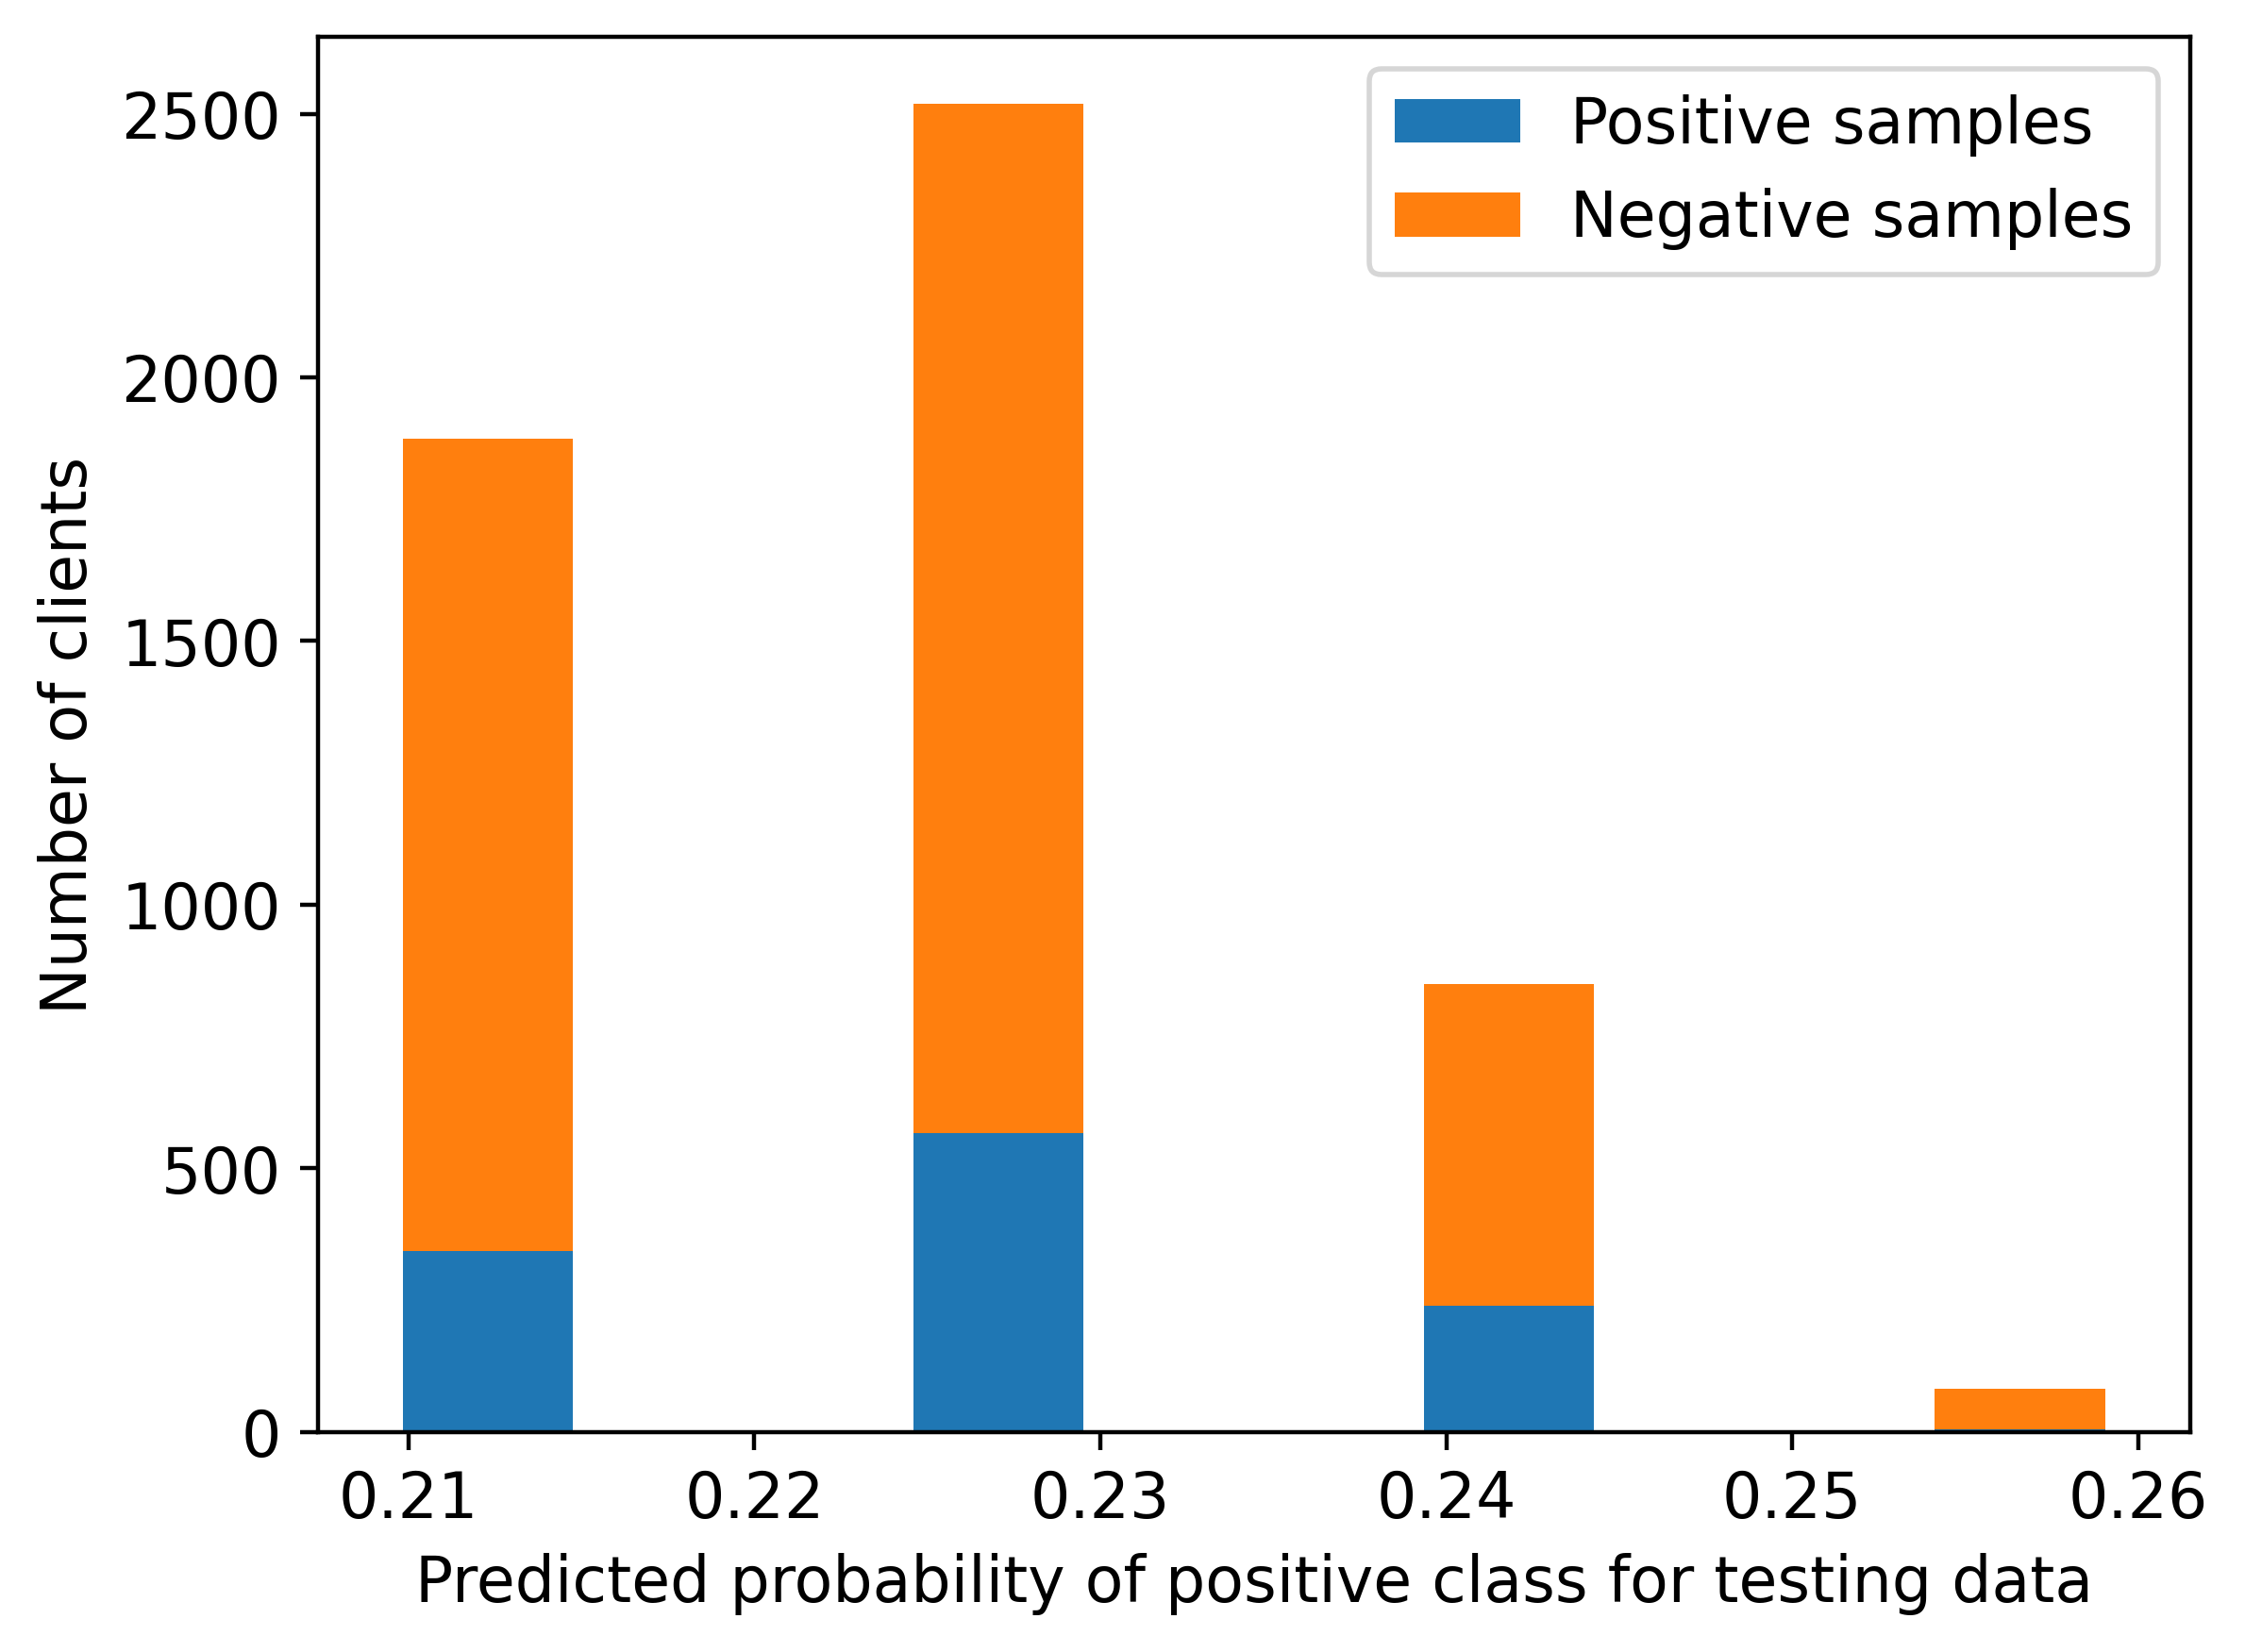

In [82]:
plt.hist([pos_sample_pos_proba, neg_sample_pos_proba], histtype='barstacked')
plt.legend(['Positive samples', 'Negative samples'])
plt.xlabel('Predicted probability of positive class for testing data')
plt.ylabel('Number of clients')

In [83]:
#gerar arrays de TPRs e FPRs da curva de ROC
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, pos_proba)

Text(0.5, 1.0, 'ROC curve for logistic regression model')

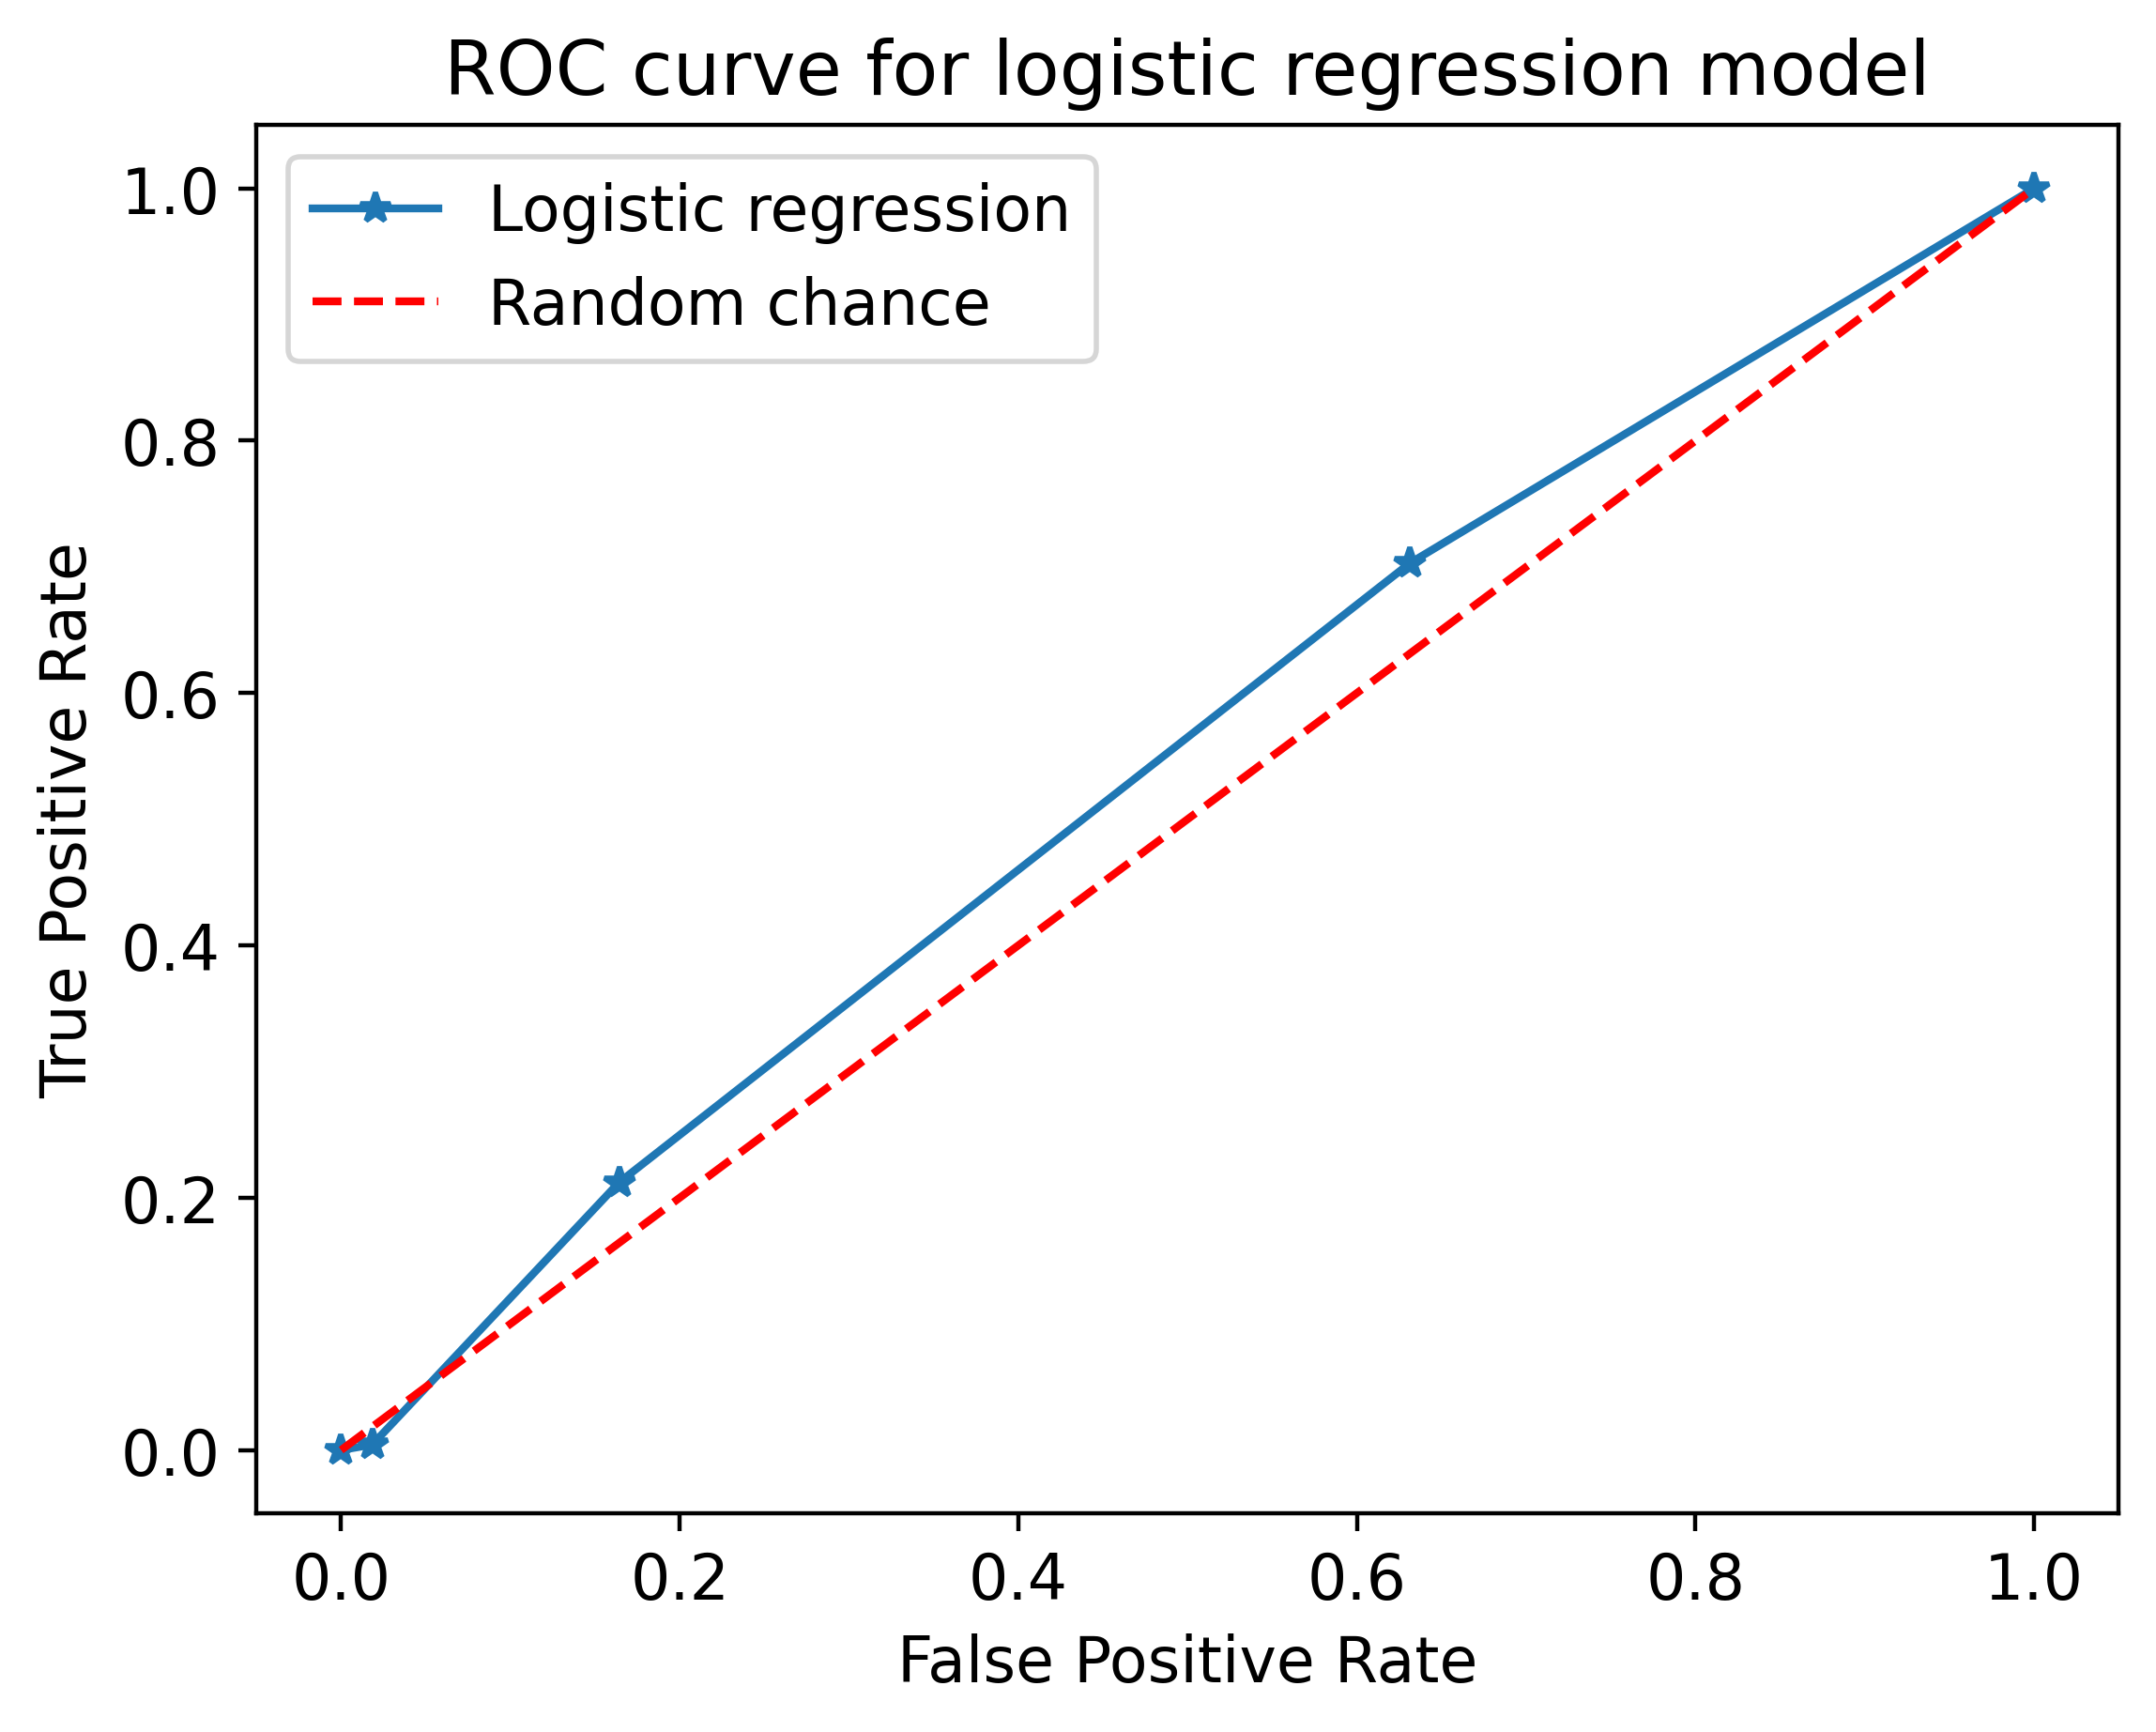

In [84]:
plt.plot(fpr, tpr, '*-')
plt.plot([0, 1], [0, 1], 'r--')
plt.legend(['Logistic regression', 'Random chance'])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve for logistic regression model')

In [85]:
thresholds

array([       inf, 0.25903847, 0.24184056, 0.22543705, 0.20983821])

In [86]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_test, pos_proba)

0.5434650477972642

In [87]:
from sklearn.metrics import precision_recall_curve
precision_recall_curve(y_test, pos_proba)

(array([0.21657604, 0.23536232, 0.26315789, 0.06097561, 1.        ]),
 array([1.        , 0.7030303 , 0.21212121, 0.004329  , 0.        ]),
 array([0.20983821, 0.22543705, 0.24184056, 0.25903847]))

# Detalhes da regressão logística e exploração de características

objetivos de aprendizado:
- criar list comprehensions em Python
- descrever como funciona a regressão logística
- formular as versões sigmóide e logit da regressão logística
- utilizar a seleção univariada para encontrar características importantes
- personalizar plotagens com a API Matplotlib
- definir o limite de decisão linear de uma regressão logística

In [91]:
import seaborn as sns  

df = pd.read_csv('Data/Chapter_1_cleaned_data.csv')

In [93]:
features_response = df.columns.tolist()
features_response[:5]

['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE']

In [94]:
features_response[-5:]

['EDUCATION_CAT', 'graduate school', 'high school', 'others', 'university']

In [97]:
items_to_remove = ['ID', 'SEX', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'graduate school', 'high school', 'none',  'others', 'university', 'EDUCATION_CAT']
items_to_remove

['ID',
 'SEX',
 'PAY_2',
 'PAY_3',
 'PAY_4',
 'PAY_5',
 'PAY_6',
 'graduate school',
 'high school',
 'none',
 'others',
 'university',
 'EDUCATION_CAT']

In [98]:
features_response = [item for item in features_response if item not in items_to_remove]
features_response

['LIMIT_BAL',
 'EDUCATION',
 'MARRIAGE',
 'AGE',
 'PAY_1',
 'BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT1',
 'PAY_AMT2',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6',
 'default payment next month']

In [99]:
corr = df[features_response].corr()
corr.iloc[0:5, 0:5]

,LIMIT_BAL,EDUCATION,MARRIAGE,AGE,PAY_1
LIMIT_BAL,1.000000,-0.232688,-0.109232,0.149157,-0.273396
EDUCATION,-0.232688,1.000000,-0.149563,0.179035,0.112653
MARRIAGE,-0.109232,-0.149563,1.000000,-0.415119,0.020723
AGE,0.149157,0.179035,-0.415119,1.000000,-0.044277
PAY_1,-0.273396,0.112653,0.020723,-0.044277,1.000000


<Axes: >

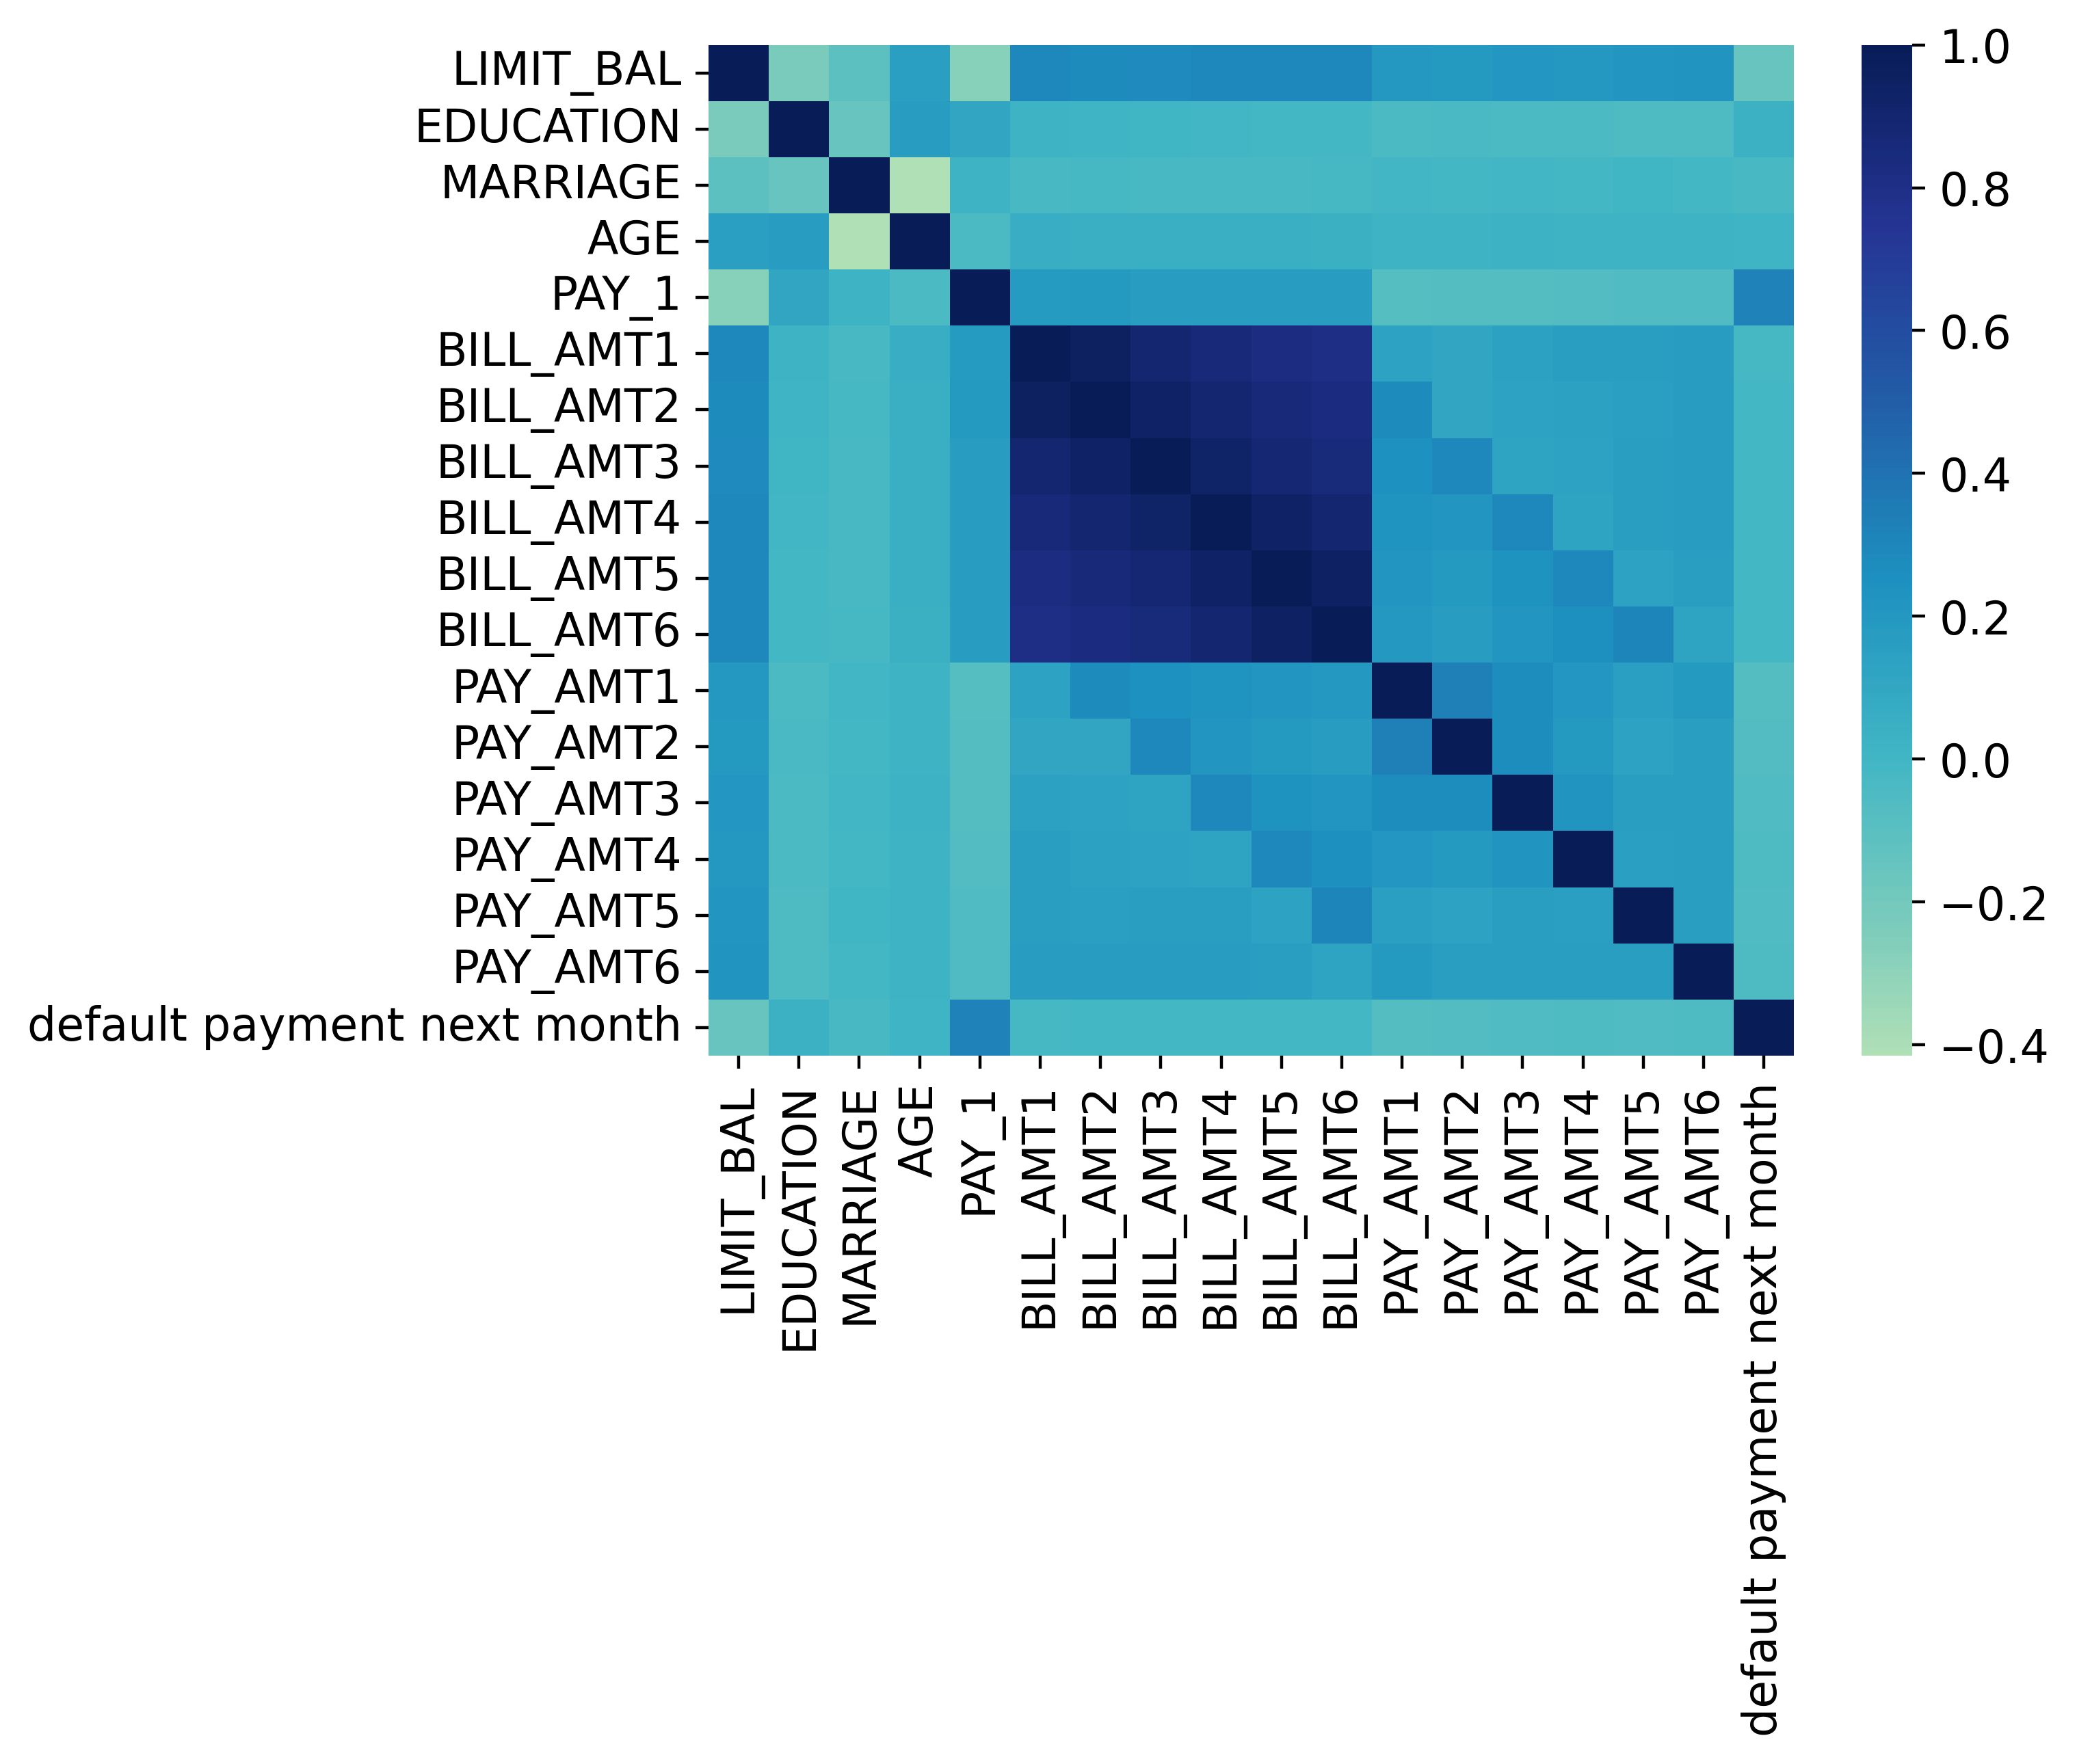

In [ ]:
sns.heatmap(corr, xticklabels=corr.columns, yticklabels=corr.columns, cmap='YlGnBu', center=0)


In [107]:
X = df[features_response].iloc[:, :-1].values
y = df[features_response].iloc[:, -1].values
print(X.shape, y.shape)

(26664, 17) (26664,)


In [111]:
from sklearn.feature_selection import f_classif
[f_stat, f_p_value] = f_classif(X, y)

In [112]:
f_test_df = pd.DataFrame({'Feature': features_response[:-1], 'F statistic': f_stat, 'p value': f_p_value}) 
f_test_df.sort_values('p value')

,Feature,F statistic,p value
4,PAY_1,3156.672300,0.000000e+00
0,LIMIT_BAL,651.324071,5.838366e-142
11,PAY_AMT1,140.612679,2.358354e-32
12,PAY_AMT2,101.408321,8.256124e-24
13,PAY_AMT3,90.023873,2.542641e-21
15,PAY_AMT5,85.843295,2.090120e-20
16,PAY_AMT6,80.420784,3.219565e-19
14,PAY_AMT4,79.640021,4.774112e-19
1,EDUCATION,32.637768,1.122175e-08
2,MARRIAGE,14.202266,1.645262e-04


In [116]:
from sklearn.feature_selection import SelectPercentile

selector = SelectPercentile(percentile=20, score_func=f_classif)

selector.fit(X, y)


,score_func,<function f_c...x7fea2b05b240>
,percentile,20


In [120]:
best_feature_ix = selector.get_support()
best_feature_ix

array([ True, False, False, False,  True, False, False, False, False,
       False, False,  True,  True, False, False, False, False])

In [121]:
features = features_response[:-1]

In [122]:
best_features = [features[counter] for counter in range(len(features)) if best_feature_ix[counter]]
best_features

['LIMIT_BAL', 'PAY_1', 'PAY_AMT1', 'PAY_AMT2']